#### why fast & slow (spindle_00)

In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_00'))

d:\mynew\demo_all


#### a=9.2 Jrt -0.2->-1.5 raw_data_a9.2_Jrt_scan

In [2]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os

# ========== 参数设置 ==========
n_runs = 10                    # 每个参数值运行 10 次
a_fixed = 9.2                  # 固定 a 值
c2tsc = 0.0                    # 固定 c2tsc
scale2 = 0.0                   # 固定 scale2

# Jrt 范围：-0.5 到 -1.5，取 11 个值
Jrt_list = np.linspace(-0.2, -1.5, 14)

print("="*60)
print("参数扫描设置")
print("="*60)
print(f"a = {a_fixed}")
print(f"Jrt 值列表: {Jrt_list}")
print(f"c2tsc: {c2tsc}")
print(f"scale2: {scale2}")
print(f"每个参数 seed 数: {n_runs}")
print(f"总运行次数: {len(Jrt_list) * n_runs}")

# ========== 创建保存目录 ==========
DATA_DIR = "data/raw_data_a9.2_Jrt_scan"
os.makedirs(DATA_DIR, exist_ok=True)

# ========== 统计已完成文件 ==========
existing_files = set()
for f in os.listdir(DATA_DIR):
    if f.endswith(".npy"):
        existing_files.add(f)
print(f"\n已存在 {len(existing_files)} 个文件")

# ========== 运行任务 ==========
total_tasks = len(Jrt_list) * n_runs
completed = 0
skipped = 0

for Jrt_val in Jrt_list:
    for seed in range(1, n_runs + 1):
        # 生成文件名
        filename = f"a_{a_fixed:.4f}_Jrt_{Jrt_val:.4f}_c2tsc_{c2tsc:.4f}_scale2_{scale2:.6f}_seed_{seed}.npy"
        save_path = os.path.join(DATA_DIR, filename)
        
        # 如果文件已存在，跳过
        if filename in existing_files:
            print(f"跳过: {filename}")
            skipped += 1
            continue
        
        # 加载默认参数并修改
        params = dp.loadDefaultParams(seed)
        
        # 固定 a 值
        params["a"] = a_fixed
        params["VT_t"] = 26 - a_fixed
        params["VT_r"] = 23 - a_fixed
        params["VB_t"] = 15 - a_fixed
        params["VB_r"] = 15 - a_fixed
        
        # 修改 Jrt
        params["Jrt"] = Jrt_val
        
        # 固定 c2tsc 和 scale2
        params["c2tsc"] = c2tsc
        params["scale2"] = scale2
        
        # 运行模型
        try:
            t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
        except Exception as e:
            print(f"失败: {filename}, 错误: {e}")
            continue
        
        # 保存 raw 信号
        np.save(save_path, {
            "t": t, "V_e": V_e, "V_i": V_i, 
            "Q_e": Q_e, "Q_i": Q_i, 
            "V_t": V_t, "V_r": V_r, 
            "Q_t": Q_t, "Q_r": Q_r,
            "a": a_fixed,
            "Jrt": Jrt_val,
            "c2tsc": c2tsc,
            "scale2": scale2,
            "seed": seed
        })
        
        completed += 1
        if completed % 10 == 0:
            print(f"进度: {completed}/{total_tasks - skipped}")

print("\n" + "="*60)
print("完成统计")
print("="*60)
print(f"总任务数: {total_tasks}")
print(f"新运行: {completed}")
print(f"跳过已存在: {skipped}")
print(f"数据保存在: {DATA_DIR}")

# ========== 显示生成的文件统计 ==========
print("\n生成的文件统计:")
for Jrt_val in Jrt_list:
    count = 0
    for f in os.listdir(DATA_DIR):
        if f.endswith(".npy") and f"Jrt_{Jrt_val:.4f}" in f:
            count += 1
    print(f"  Jrt={Jrt_val:.4f}: {count} 个文件")

参数扫描设置
a = 9.2
Jrt 值列表: [-0.2 -0.3 -0.4 -0.5 -0.6 -0.7 -0.8 -0.9 -1.  -1.1 -1.2 -1.3 -1.4 -1.5]
c2tsc: 0.0
scale2: 0.0
每个参数 seed 数: 10
总运行次数: 140

已存在 0 个文件
进度: 10/140
进度: 20/140
进度: 30/140
进度: 40/140
进度: 50/140
进度: 60/140
进度: 70/140
进度: 80/140
进度: 90/140
进度: 100/140
进度: 110/140
进度: 120/140
进度: 130/140
进度: 140/140

完成统计
总任务数: 140
新运行: 140
跳过已存在: 0
数据保存在: data/raw_data_a9.2_Jrt_scan

生成的文件统计:
  Jrt=-0.2000: 10 个文件
  Jrt=-0.3000: 10 个文件
  Jrt=-0.4000: 10 个文件
  Jrt=-0.5000: 10 个文件
  Jrt=-0.6000: 10 个文件
  Jrt=-0.7000: 10 个文件
  Jrt=-0.8000: 10 个文件
  Jrt=-0.9000: 10 个文件
  Jrt=-1.0000: 10 个文件
  Jrt=-1.1000: 10 个文件
  Jrt=-1.2000: 10 个文件
  Jrt=-1.3000: 10 个文件
  Jrt=-1.4000: 10 个文件
  Jrt=-1.5000: 10 个文件


#### Jrt_scan spindles.csv

In [3]:
import numpy as np
import pandas as pd
import yasa
import glob
import os

# ========== 1. 参数设置 ==========
sf = 10000  # 采样率
DATA_DIR = "data/raw_data_a9.2_Jrt_scan"
OUTPUT_CSV = "data/analysis_data/spindles_a9.2_Jrt_scan.csv"

# ========== 2. 读取所有文件 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
print(f"找到 {len(file_list)} 个文件")

# ========== 3. 检测纺锤波 ==========
all_spindles = []

for file_path in file_list:
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    
    a_val = float(parts[1])
    Jrt_val = float(parts[3])
    c2tsc = float(parts[5])
    scale2 = float(parts[7])
    seed = int(parts[9])
    
    data = np.load(file_path, allow_pickle=True).item()
    V_t = data["V_t"]
    
    # 检测快纺锤波 (12-16 Hz)
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12, 16), duration=(0.3, 2))
    if sp_fast is not None:
        df_fast = sp_fast.summary()
        for _, row in df_fast.iterrows():
            all_spindles.append({
                "a": a_val,
                "Jrt": Jrt_val,
                "c2tsc": c2tsc,
                "scale2": scale2,
                "seed": seed,
                "type": "fast",
                "start": row["Start"],
                "peak": row["Peak"],
                "end": row["End"],
                "duration": row["Duration"],
                "frequency": row["Frequency"],
                "amplitude": row["Amplitude"],
            })
    
    # 检测慢纺锤波 (8-12 Hz)
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8, 12), duration=(0.3, 2))
    if sp_slow is not None:
        df_slow = sp_slow.summary()
        for _, row in df_slow.iterrows():
            all_spindles.append({
                "a": a_val,
                "Jrt": Jrt_val,
                "c2tsc": c2tsc,
                "scale2": scale2,
                "seed": seed,
                "type": "slow",
                "start": row["Start"],
                "peak": row["Peak"],
                "end": row["End"],
                "duration": row["Duration"],
                "frequency": row["Frequency"],
                "amplitude": row["Amplitude"],
            })

# ========== 4. 保存 CSV ==========
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
df_spindles = pd.DataFrame(all_spindles)
df_spindles.to_csv(OUTPUT_CSV, index=False)

print(f"\n总共检测到 {len(df_spindles)} 个纺锤波")
print(f"快纺锤波: {len(df_spindles[df_spindles['type'] == 'fast'])}")
print(f"慢纺锤波: {len(df_spindles[df_spindles['type'] == 'slow'])}")
print(f"CSV 已保存: {OUTPUT_CSV}")

# ========== 5. 打印各 Jrt 值统计 ==========
print("\n各 Jrt 值统计:")
for Jrt_val in sorted(df_spindles['Jrt'].unique()):
    subset = df_spindles[df_spindles['Jrt'] == Jrt_val]
    fast_count = len(subset[subset['type'] == 'fast'])
    slow_count = len(subset[subset['type'] == 'slow'])
    print(f"  Jrt={Jrt_val:.4f}: fast={fast_count}, slow={slow_count}, total={len(subset)}")

找到 140 个文件


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
29-Jul-26 19:14:11 | WARNING | No spindle were found in channel CHAN000.
29-Jul-26 19:14:11 | WARNING | No spindles were found in data. Returning None.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
29-Jul-26 19:14:12 | WARNING | No spindle were found in channel CHAN000.
29-Jul-26 19:14:12 | WARNING | No spindles were found in data. Returning None.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finis


总共检测到 725 个纺锤波
快纺锤波: 399
慢纺锤波: 326
CSV 已保存: data/analysis_data/spindles_a9.2_Jrt_scan.csv

各 Jrt 值统计:
  Jrt=-1.1000: fast=3, slow=0, total=3
  Jrt=-1.0000: fast=3, slow=0, total=3
  Jrt=-0.9000: fast=10, slow=0, total=10
  Jrt=-0.8000: fast=45, slow=1, total=46
  Jrt=-0.7000: fast=77, slow=0, total=77
  Jrt=-0.6000: fast=80, slow=13, total=93
  Jrt=-0.5000: fast=110, slow=59, total=169
  Jrt=-0.4000: fast=55, slow=76, total=131
  Jrt=-0.3000: fast=16, slow=95, total=111
  Jrt=-0.2000: fast=0, slow=82, total=82


### 不同Jrt所引发的快慢纺锤个数等分析

读取 725 个纺锤波
a = 9.2

Jrt 值: [np.float64(-1.1), np.float64(-1.0), np.float64(-0.9), np.float64(-0.8), np.float64(-0.7), np.float64(-0.6), np.float64(-0.5), np.float64(-0.4), np.float64(-0.3), np.float64(-0.2)]

平均纺锤波个数统计（每个 seed 先统计，再对 seed 平均）

--- Jrt = -1.100 ---
  fast: mean_count=1.0±0.0 (n_seeds=3)

--- Jrt = -1.000 ---
  fast: mean_count=1.0±0.0 (n_seeds=3)

--- Jrt = -0.900 ---
  fast: mean_count=1.1±0.3 (n_seeds=9)

--- Jrt = -0.800 ---
  fast: mean_count=4.5±0.8 (n_seeds=10)
  slow: mean_count=1.0±nan (n_seeds=1)

--- Jrt = -0.700 ---
  fast: mean_count=7.7±1.4 (n_seeds=10)

--- Jrt = -0.600 ---
  fast: mean_count=8.0±1.3 (n_seeds=10)
  slow: mean_count=1.9±0.4 (n_seeds=7)

--- Jrt = -0.500 ---
  fast: mean_count=11.0±1.5 (n_seeds=10)
  slow: mean_count=5.9±3.7 (n_seeds=10)

--- Jrt = -0.400 ---
  fast: mean_count=5.5±1.8 (n_seeds=10)
  slow: mean_count=7.6±2.5 (n_seeds=10)

--- Jrt = -0.300 ---
  fast: mean_count=2.0±1.3 (n_seeds=8)
  slow: mean_count=9.5±1.1 (n_seeds=10)

--

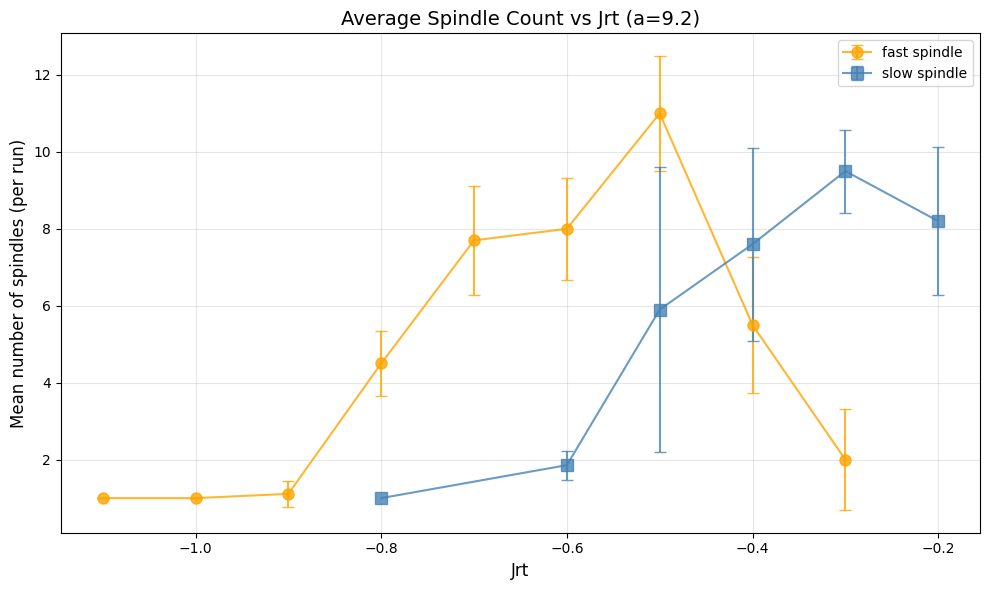

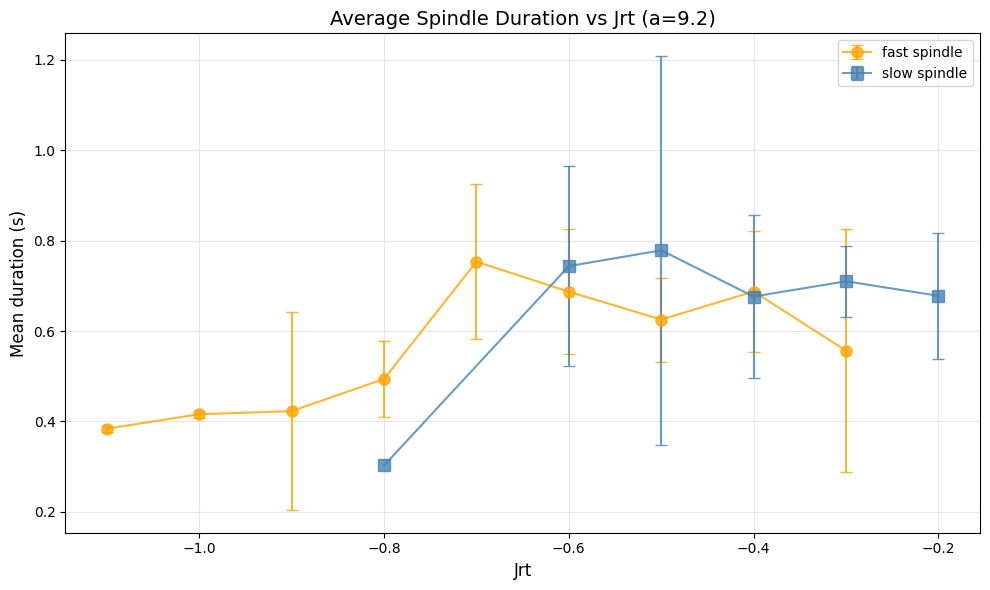

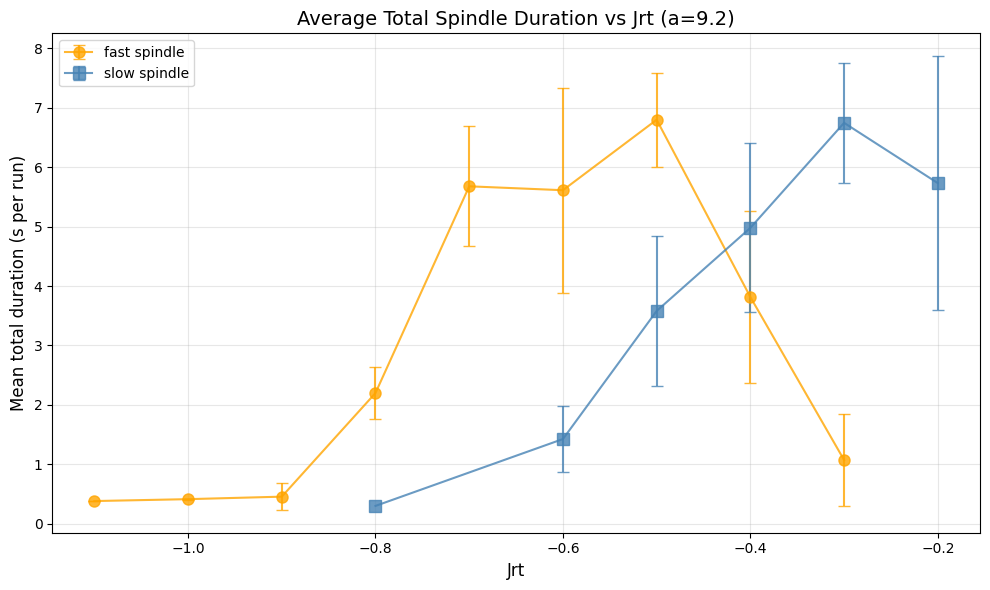

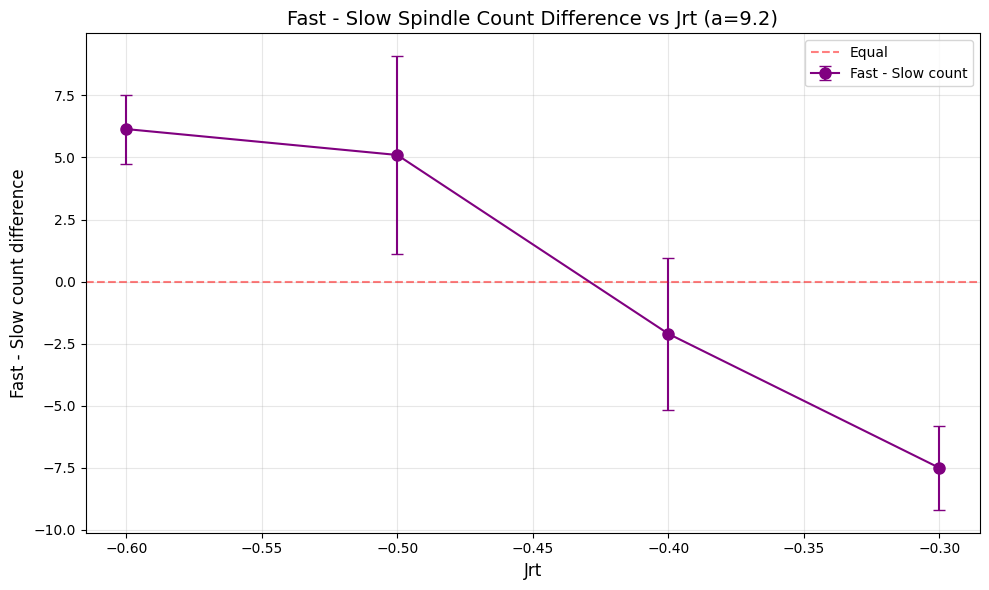


统计检验：每个 Jrt 下快慢纺锤波个数比较
Jrt=-0.800: fast_n=10, slow_n=1, fast_mean=4.5, slow_mean=1.0, p=0.1356 (不显著)
Jrt=-0.600: fast_n=10, slow_n=7, fast_mean=8.0, slow_mean=1.9, p=0.0005 (显著)
Jrt=-0.500: fast_n=10, slow_n=10, fast_mean=11.0, slow_mean=5.9, p=0.0023 (显著)
Jrt=-0.400: fast_n=10, slow_n=10, fast_mean=5.5, slow_mean=7.6, p=0.0727 (不显著)
Jrt=-0.300: fast_n=8, slow_n=10, fast_mean=2.0, slow_mean=9.5, p=0.0003 (显著)

最佳参数总结

快纺锤波个数最多: Jrt=-0.500, fast_mean=11.0
慢纺锤波个数最多: Jrt=-0.300, slow_mean=9.5

快纺锤波总时长最多: Jrt=-0.500, total=6.80s
慢纺锤波总时长最多: Jrt=-0.300, total=6.74s


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ========== 1. 读取数据 ==========
CSV_PATH = "data/analysis_data/spindles_a9.2_Jrt_scan.csv"
df = pd.read_csv(CSV_PATH)

print(f"读取 {len(df)} 个纺锤波")

# 获取 a 值（从数据中提取）
a_fixed = df['a'].iloc[0] if 'a' in df.columns else 9.2
print(f"a = {a_fixed}")

# ========== 2. 查看 Jrt 的取值范围 ==========
Jrt_values = sorted(df['Jrt'].unique())
print(f"\nJrt 值: {Jrt_values}")

# ========== 3. 按 Jrt, seed, type 分组统计每个 seed 的个数和总时长 ==========
seed_counts = df.groupby(['Jrt', 'seed', 'type']).size().reset_index(name='count')
seed_total_duration = df.groupby(['Jrt', 'seed', 'type'])['duration'].sum().reset_index(name='total_duration')

# 再按 Jrt 和 type 分组，计算所有 seed 的平均个数和标准差
count_stats = seed_counts.groupby(['Jrt', 'type']).agg(
    mean_count=('count', 'mean'),
    std_count=('count', 'std'),
    n_seeds=('count', 'count')
).reset_index()

# 再按 Jrt 和 type 分组，计算所有 seed 的平均总时长和标准差
total_duration_stats = seed_total_duration.groupby(['Jrt', 'type']).agg(
    mean_total_duration=('total_duration', 'mean'),
    std_total_duration=('total_duration', 'std'),
    n_seeds=('total_duration', 'count')
).reset_index()

print("\n" + "="*60)
print("平均纺锤波个数统计（每个 seed 先统计，再对 seed 平均）")
print("="*60)

for Jrt_val in Jrt_values:
    print(f"\n--- Jrt = {Jrt_val:.3f} ---")
    for spindle_type in ['fast', 'slow']:
        subset = count_stats[(count_stats['Jrt'] == Jrt_val) & 
                             (count_stats['type'] == spindle_type)]
        if len(subset) > 0:
            row = subset.iloc[0]
            print(f"  {spindle_type}: mean_count={row['mean_count']:.1f}±{row['std_count']:.1f} (n_seeds={row['n_seeds']:.0f})")

# ========== 4. 画图：平均纺锤波个数（折线图，带误差棒）==========
fig, ax = plt.subplots(figsize=(10, 6))

for spindle_type, color, marker in [('fast', 'orange', 'o'), ('slow', 'steelblue', 's')]:
    subset = count_stats[count_stats['type'] == spindle_type]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jrt')
        ax.errorbar(subset_sorted['Jrt'], subset_sorted['mean_count'], 
                    yerr=subset_sorted['std_count'],
                    fmt=f'{marker}-', color=color, capsize=4,
                    label=f'{spindle_type} spindle', 
                    markersize=8, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Jrt', fontsize=12)
ax.set_ylabel('Mean number of spindles (per run)', fontsize=12)
ax.set_title(f'Average Spindle Count vs Jrt (a={a_fixed})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 5. 画图：平均持续时长（折线图，带误差棒）==========
# 先按 Jrt, seed, type 分组统计每个 seed 的平均时长
seed_durations = df.groupby(['Jrt', 'seed', 'type'])['duration'].mean().reset_index(name='mean_duration')

# 再按 Jrt 和 type 分组，计算所有 seed 的平均时长和标准差
duration_stats = seed_durations.groupby(['Jrt', 'type']).agg(
    mean_duration=('mean_duration', 'mean'),
    std_duration=('mean_duration', 'std'),
    n_seeds=('mean_duration', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

for spindle_type, color, marker in [('fast', 'orange', 'o'), ('slow', 'steelblue', 's')]:
    subset = duration_stats[duration_stats['type'] == spindle_type]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jrt')
        ax.errorbar(subset_sorted['Jrt'], subset_sorted['mean_duration'], 
                    yerr=subset_sorted['std_duration'],
                    fmt=f'{marker}-', color=color, capsize=4,
                    label=f'{spindle_type} spindle', 
                    markersize=8, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Jrt', fontsize=12)
ax.set_ylabel('Mean duration (s)', fontsize=12)
ax.set_title(f'Average Spindle Duration vs Jrt (a={a_fixed})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 6. 画图：平均总时长（折线图，带误差棒）==========
fig, ax = plt.subplots(figsize=(10, 6))

for spindle_type, color, marker in [('fast', 'orange', 'o'), ('slow', 'steelblue', 's')]:
    subset = total_duration_stats[total_duration_stats['type'] == spindle_type]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jrt')
        ax.errorbar(subset_sorted['Jrt'], subset_sorted['mean_total_duration'], 
                    yerr=subset_sorted['std_total_duration'],
                    fmt=f'{marker}-', color=color, capsize=4,
                    label=f'{spindle_type} spindle', 
                    markersize=8, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Jrt', fontsize=12)
ax.set_ylabel('Mean total duration (s per run)', fontsize=12)
ax.set_title(f'Average Total Spindle Duration vs Jrt (a={a_fixed})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 7. 画图：快慢差值（个数差值）==========
fast_stats = count_stats[count_stats['type'] == 'fast'][['Jrt', 'mean_count', 'std_count']].rename(
    columns={'mean_count': 'fast_mean', 'std_count': 'fast_std'})
slow_stats = count_stats[count_stats['type'] == 'slow'][['Jrt', 'mean_count', 'std_count']].rename(
    columns={'mean_count': 'slow_mean', 'std_count': 'slow_std'})

diff_stats = pd.merge(fast_stats, slow_stats, on='Jrt', how='outer')
diff_stats = diff_stats.dropna()
diff_stats['diff'] = diff_stats['fast_mean'] - diff_stats['slow_mean']
diff_stats['diff_std'] = np.sqrt(diff_stats['fast_std']**2 + diff_stats['slow_std']**2)

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(diff_stats['Jrt'], diff_stats['diff'], 
            yerr=diff_stats['diff_std'],
            fmt='o-', color='purple', capsize=4,
            label='Fast - Slow count', markersize=8, linewidth=1.5)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Equal')
ax.set_xlabel('Jrt', fontsize=12)
ax.set_ylabel('Fast - Slow count difference', fontsize=12)
ax.set_title(f'Fast - Slow Spindle Count Difference vs Jrt (a={a_fixed})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 8. 统计检验 ==========
print("\n" + "="*60)
print("统计检验：每个 Jrt 下快慢纺锤波个数比较")
print("="*60)

for Jrt_val in Jrt_values:
    fast_counts_seed = seed_counts[(seed_counts['Jrt'] == Jrt_val) & 
                                   (seed_counts['type'] == 'fast')]['count'].values
    slow_counts_seed = seed_counts[(seed_counts['Jrt'] == Jrt_val) & 
                                   (seed_counts['type'] == 'slow')]['count'].values
    
    if len(fast_counts_seed) > 0 and len(slow_counts_seed) > 0:
        u, p = mannwhitneyu(fast_counts_seed, slow_counts_seed)
        print(f"Jrt={Jrt_val:.3f}: fast_n={len(fast_counts_seed)}, slow_n={len(slow_counts_seed)}, "
              f"fast_mean={np.mean(fast_counts_seed):.1f}, slow_mean={np.mean(slow_counts_seed):.1f}, "
              f"p={p:.4f} ({'显著' if p < 0.05 else '不显著'})")

# ========== 9. 找最佳参数 ==========
print("\n" + "="*60)
print("最佳参数总结")
print("="*60)

# 快纺锤波最多的 Jrt
fast_max_idx = count_stats[count_stats['type'] == 'fast']['mean_count'].idxmax()
best_Jrt_fast = count_stats.loc[fast_max_idx, 'Jrt']
best_fast = count_stats.loc[fast_max_idx, 'mean_count']

# 慢纺锤波最多的 Jrt
slow_max_idx = count_stats[count_stats['type'] == 'slow']['mean_count'].idxmax()
best_Jrt_slow = count_stats.loc[slow_max_idx, 'Jrt']
best_slow = count_stats.loc[slow_max_idx, 'mean_count']

# 总时长最多的 Jrt
fast_total_max_idx = total_duration_stats[total_duration_stats['type'] == 'fast']['mean_total_duration'].idxmax()
best_Jrt_fast_total = total_duration_stats.loc[fast_total_max_idx, 'Jrt']
best_fast_total = total_duration_stats.loc[fast_total_max_idx, 'mean_total_duration']

slow_total_max_idx = total_duration_stats[total_duration_stats['type'] == 'slow']['mean_total_duration'].idxmax()
best_Jrt_slow_total = total_duration_stats.loc[slow_total_max_idx, 'Jrt']
best_slow_total = total_duration_stats.loc[slow_total_max_idx, 'mean_total_duration']

print(f"\n快纺锤波个数最多: Jrt={best_Jrt_fast:.3f}, fast_mean={best_fast:.1f}")
print(f"慢纺锤波个数最多: Jrt={best_Jrt_slow:.3f}, slow_mean={best_slow:.1f}")
print(f"\n快纺锤波总时长最多: Jrt={best_Jrt_fast_total:.3f}, total={best_fast_total:.2f}s")
print(f"慢纺锤波总时长最多: Jrt={best_Jrt_slow_total:.3f}, total={best_slow_total:.2f}s")

In [5]:
alkhgsldg

NameError: name 'alkhgsldg' is not defined

读取 1929 个纺锤波

各 Jrt 值纺锤波数量:
  Jrt=-1.500: fast=7, slow=0
  Jrt=-1.400: fast=5, slow=0
  Jrt=-1.300: fast=55, slow=1
  Jrt=-1.200: fast=73, slow=1
  Jrt=-1.100: fast=90, slow=5
  Jrt=-1.000: fast=81, slow=8
  Jrt=-0.900: fast=80, slow=16
  Jrt=-0.800: fast=65, slow=59
  Jrt=-0.700: fast=76, slow=75
  Jrt=-0.675: fast=62, slow=92
  Jrt=-0.650: fast=50, slow=80
  Jrt=-0.625: fast=64, slow=84
  Jrt=-0.600: fast=61, slow=70
  Jrt=-0.575: fast=65, slow=80
  Jrt=-0.550: fast=54, slow=90
  Jrt=-0.525: fast=49, slow=92
  Jrt=-0.500: fast=33, slow=87


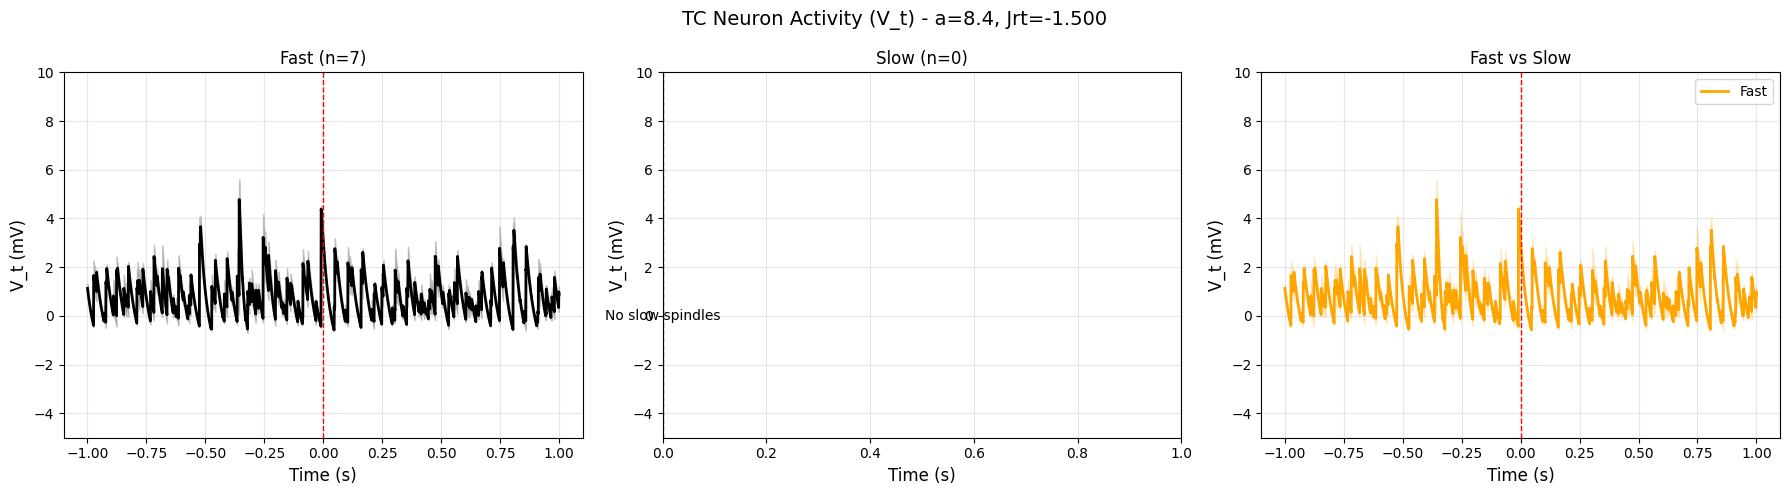

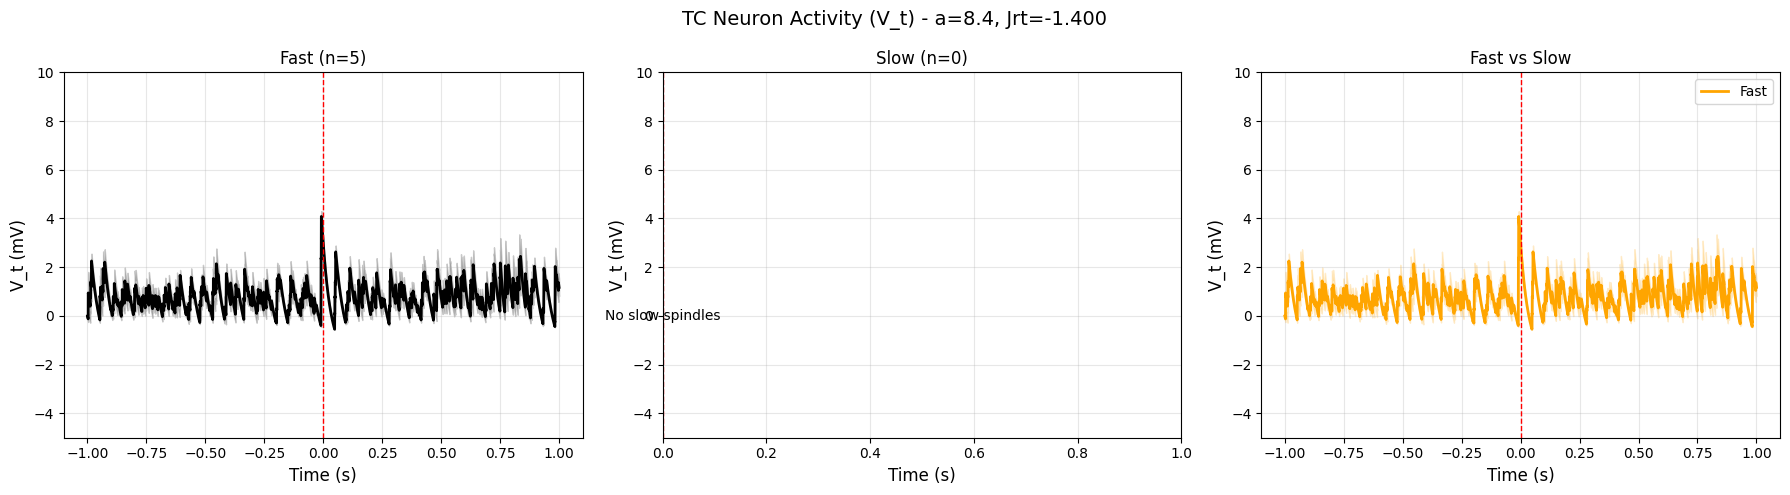

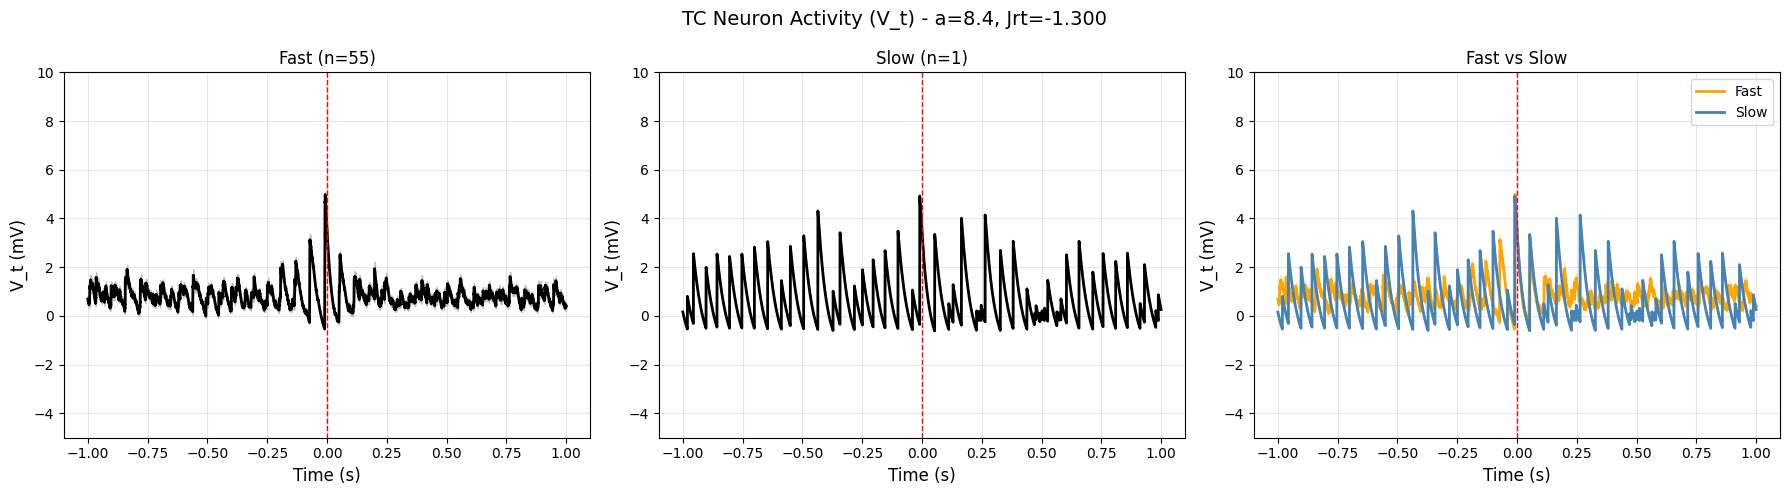

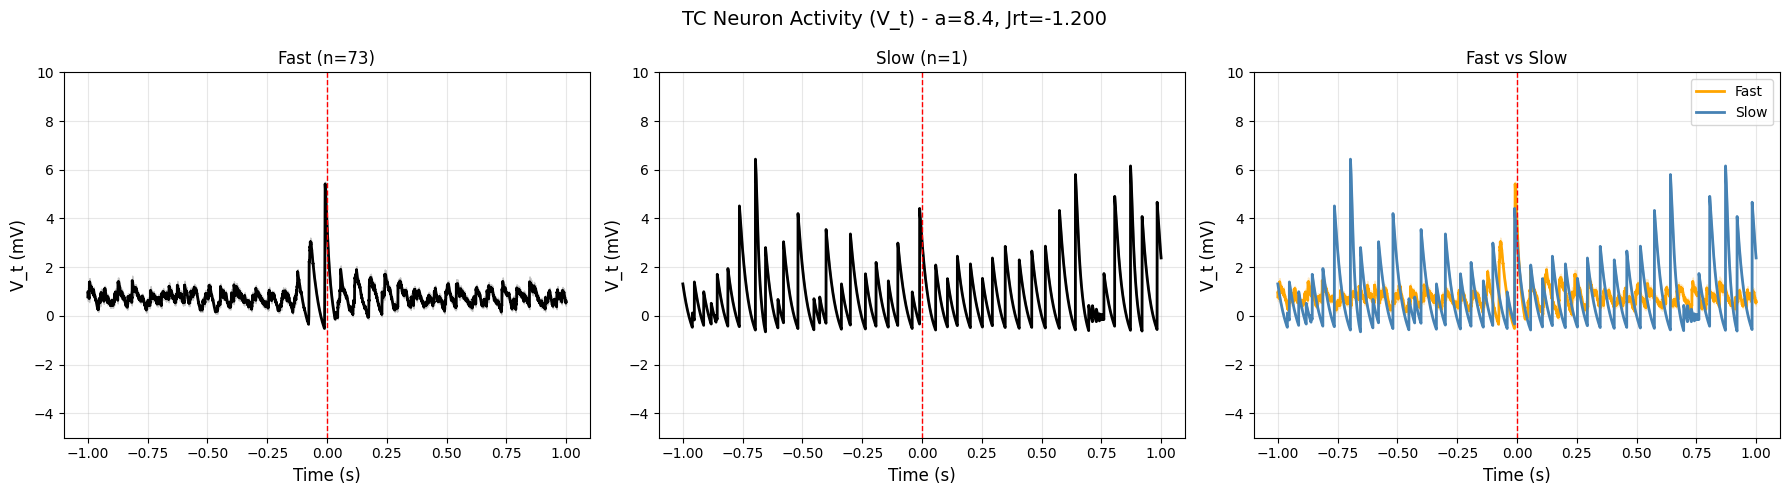

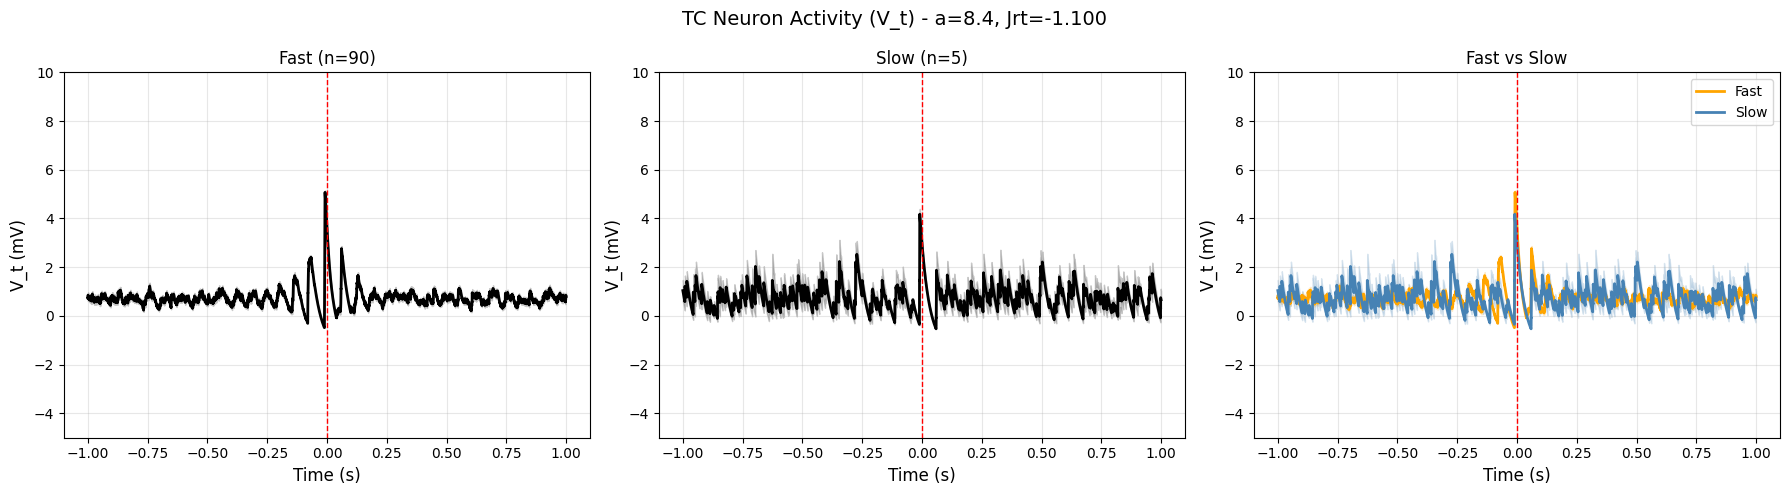

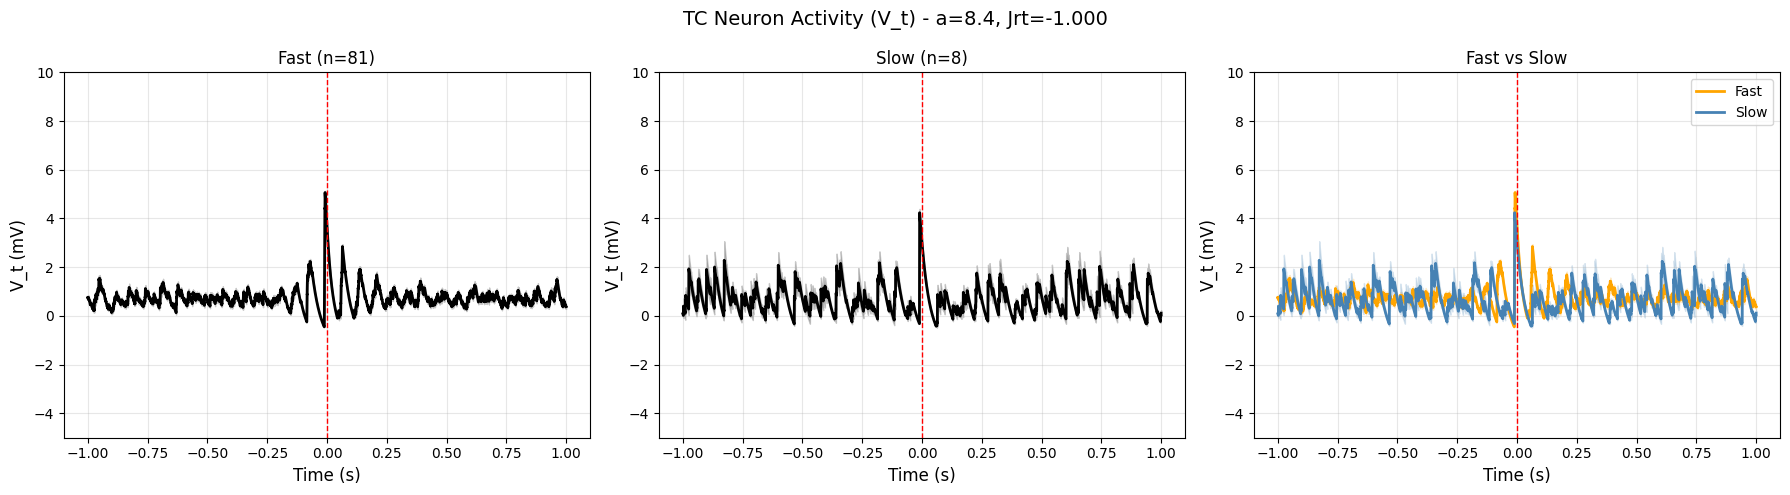

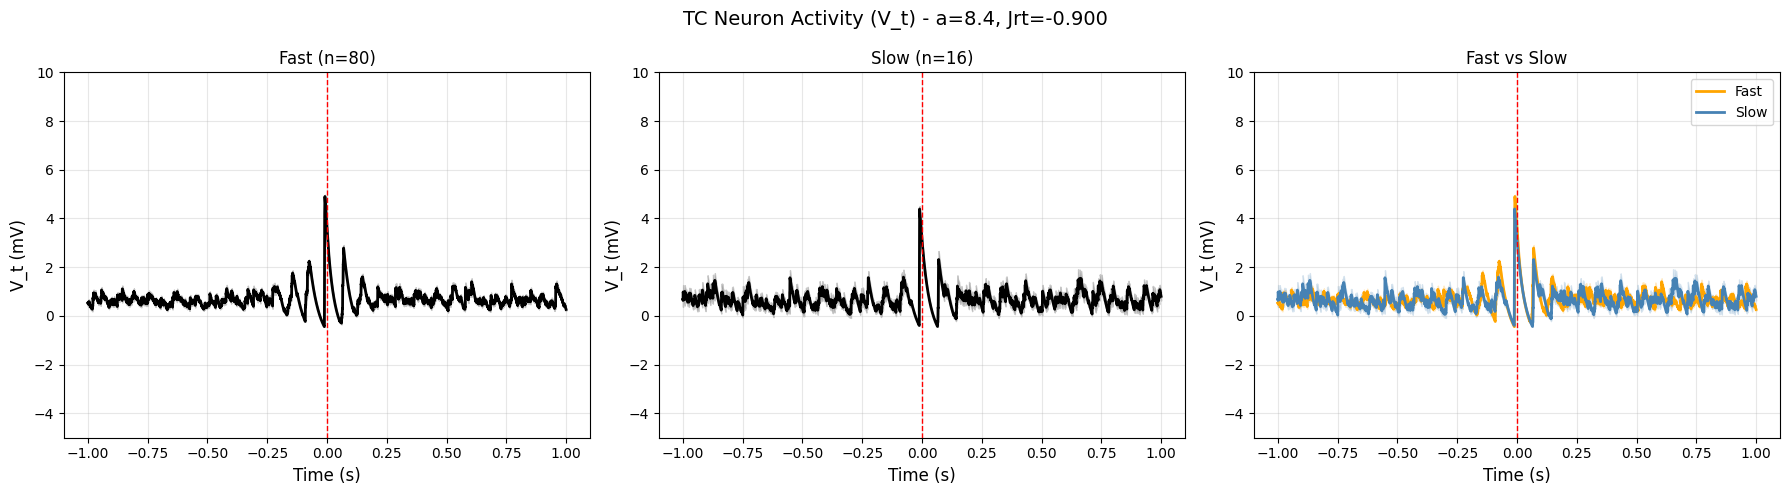

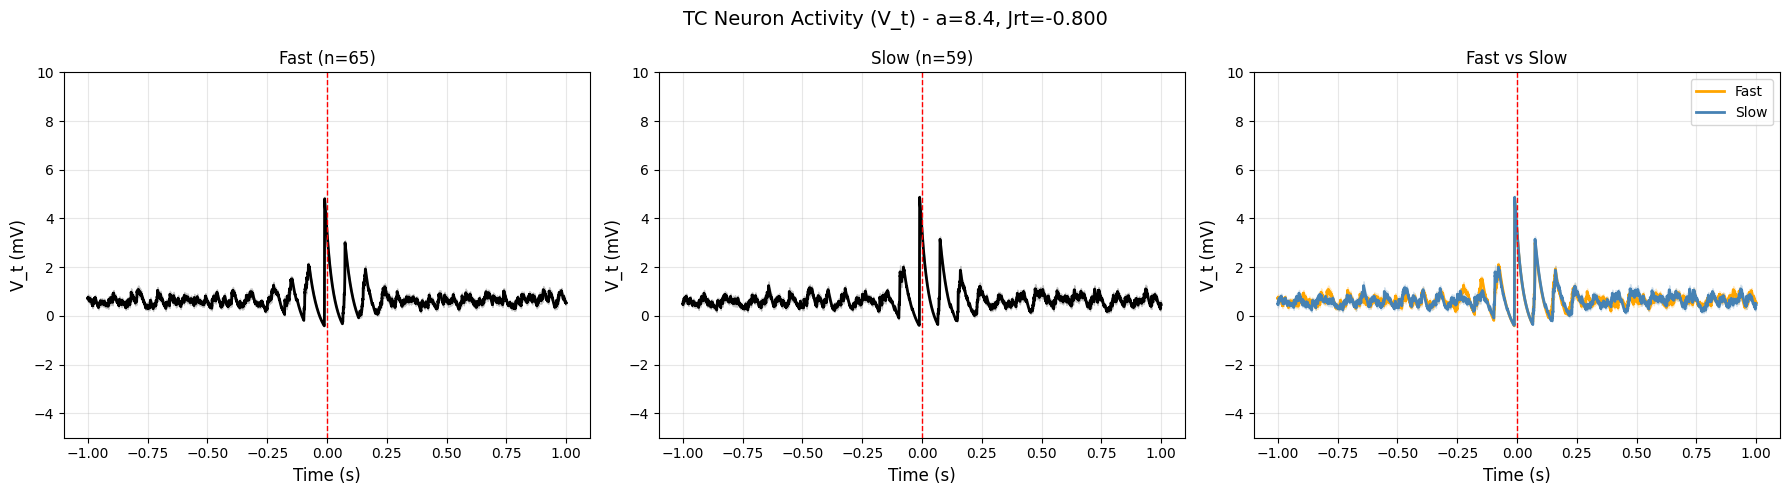

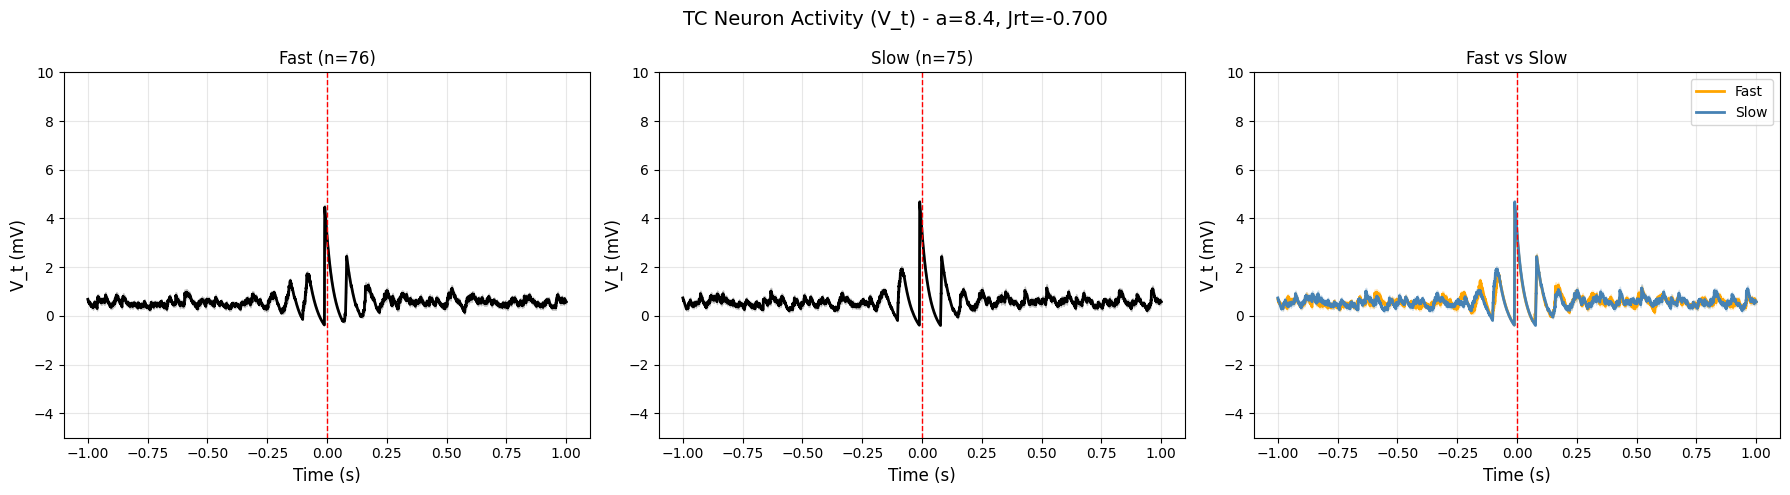

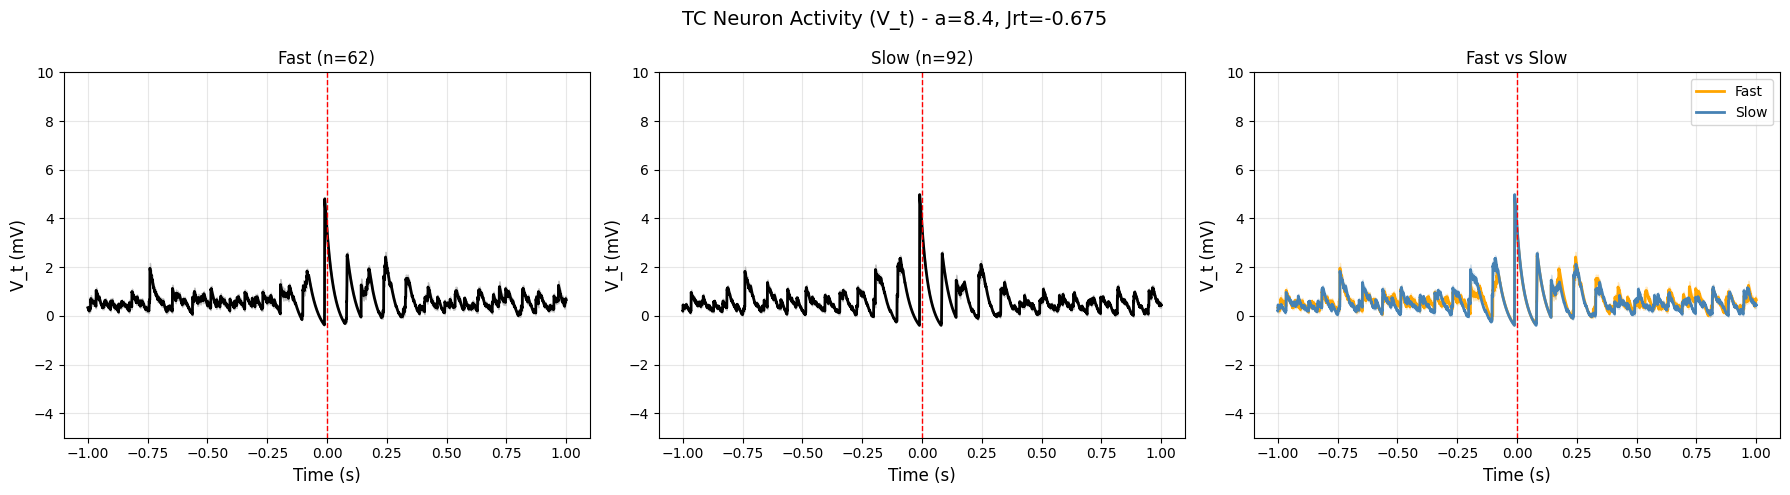

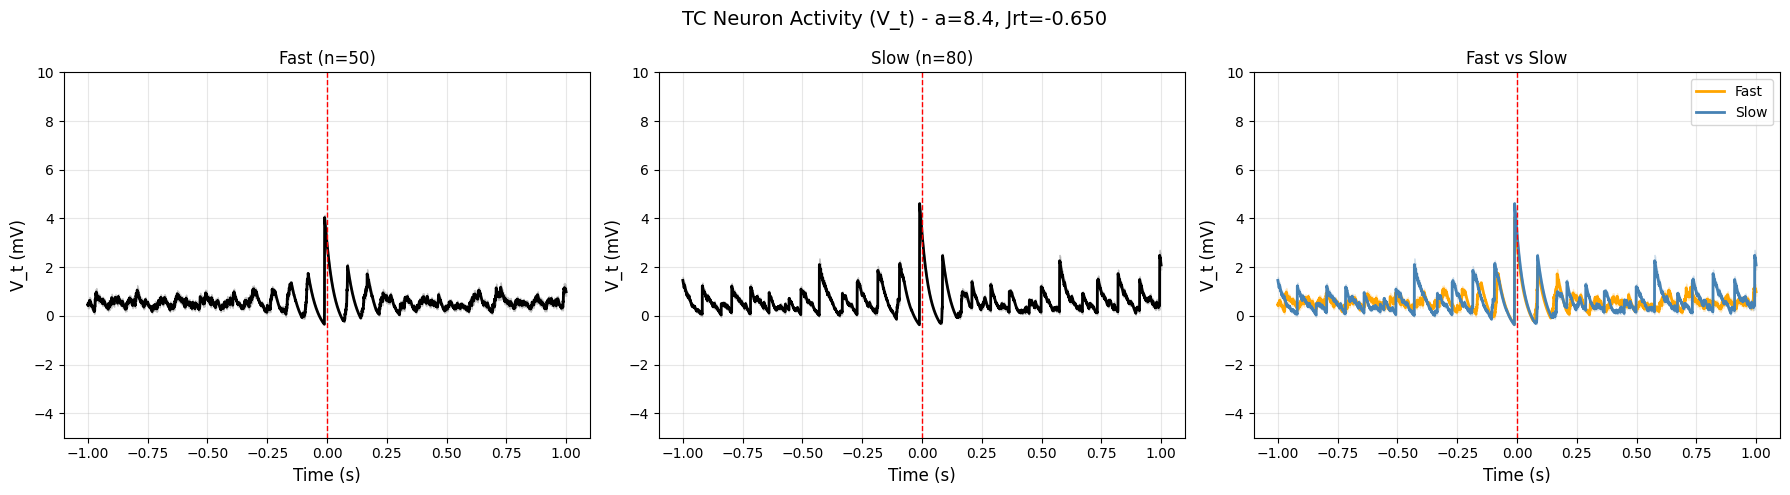

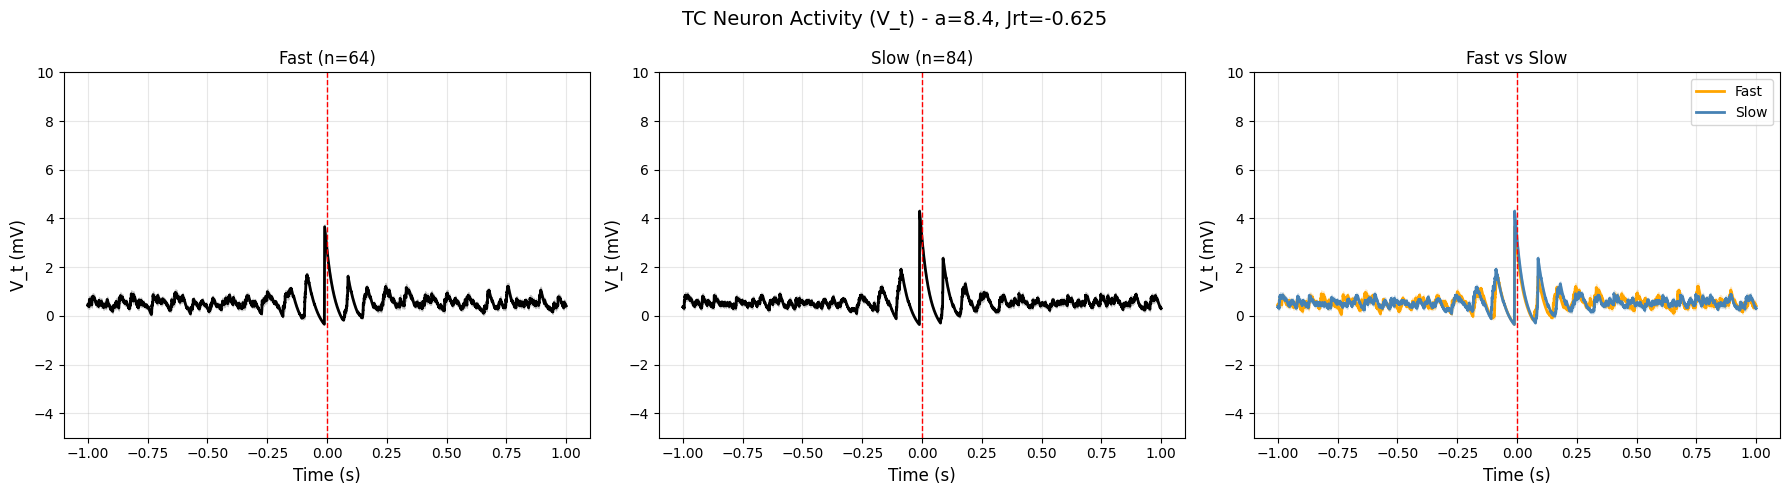

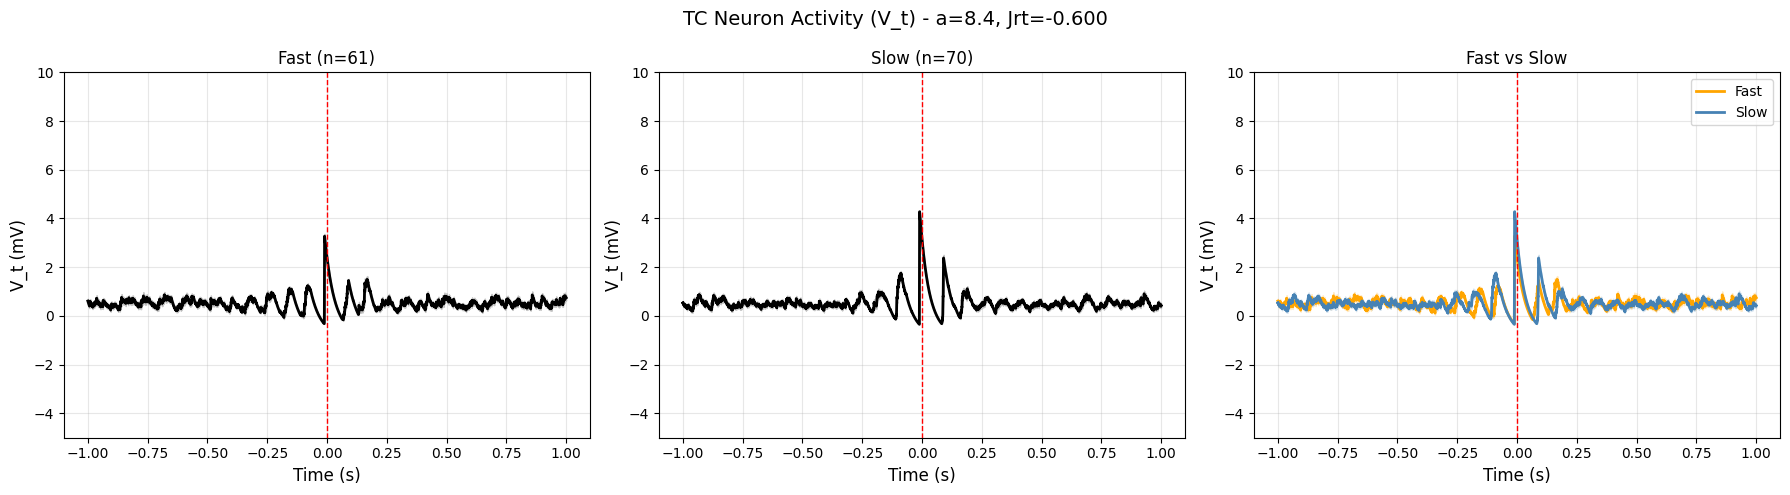

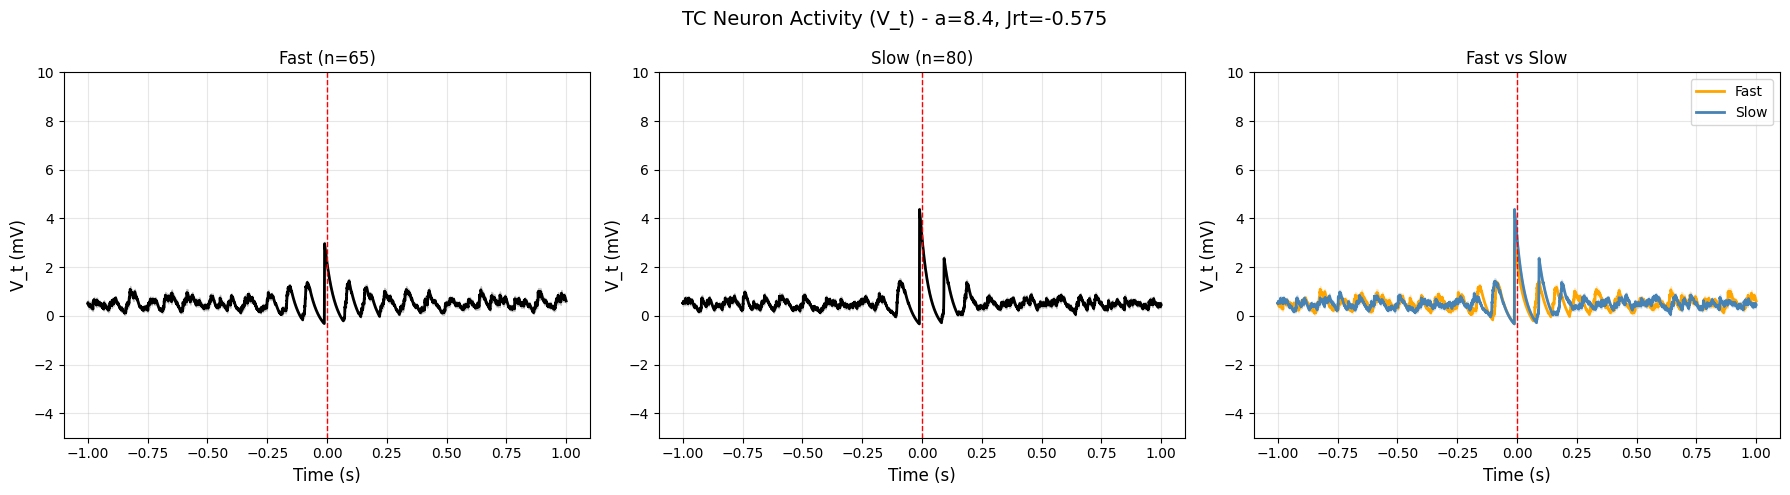

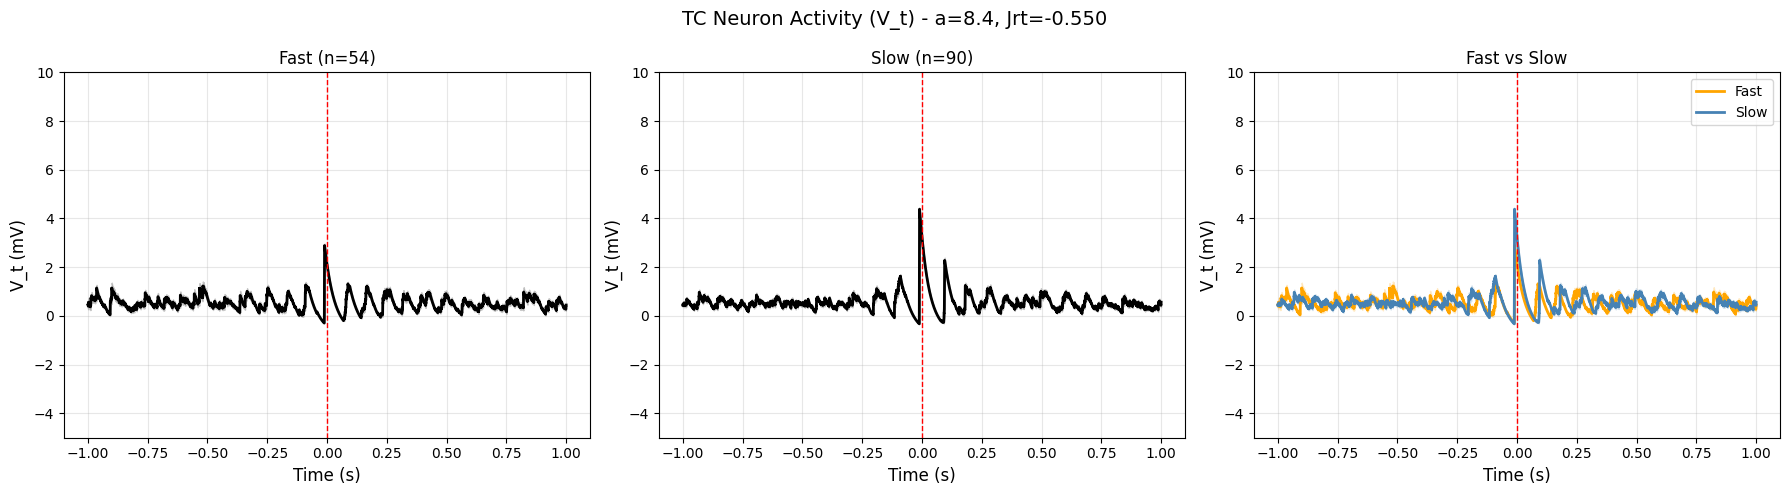

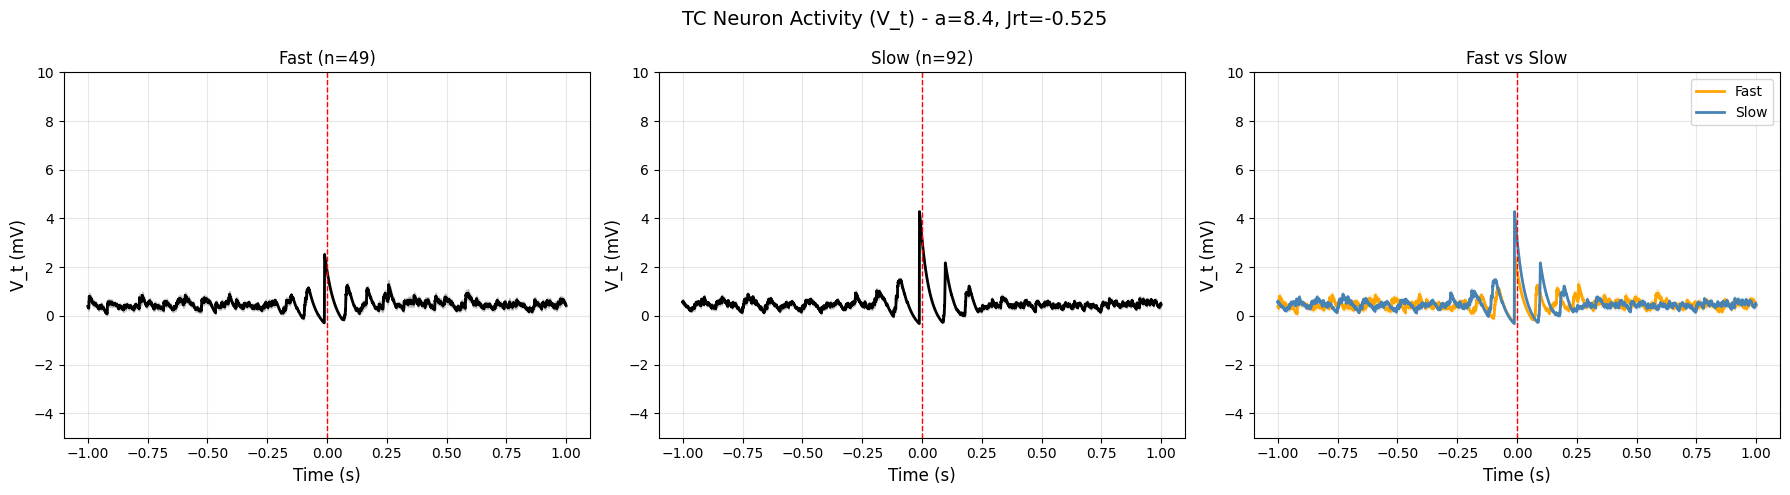

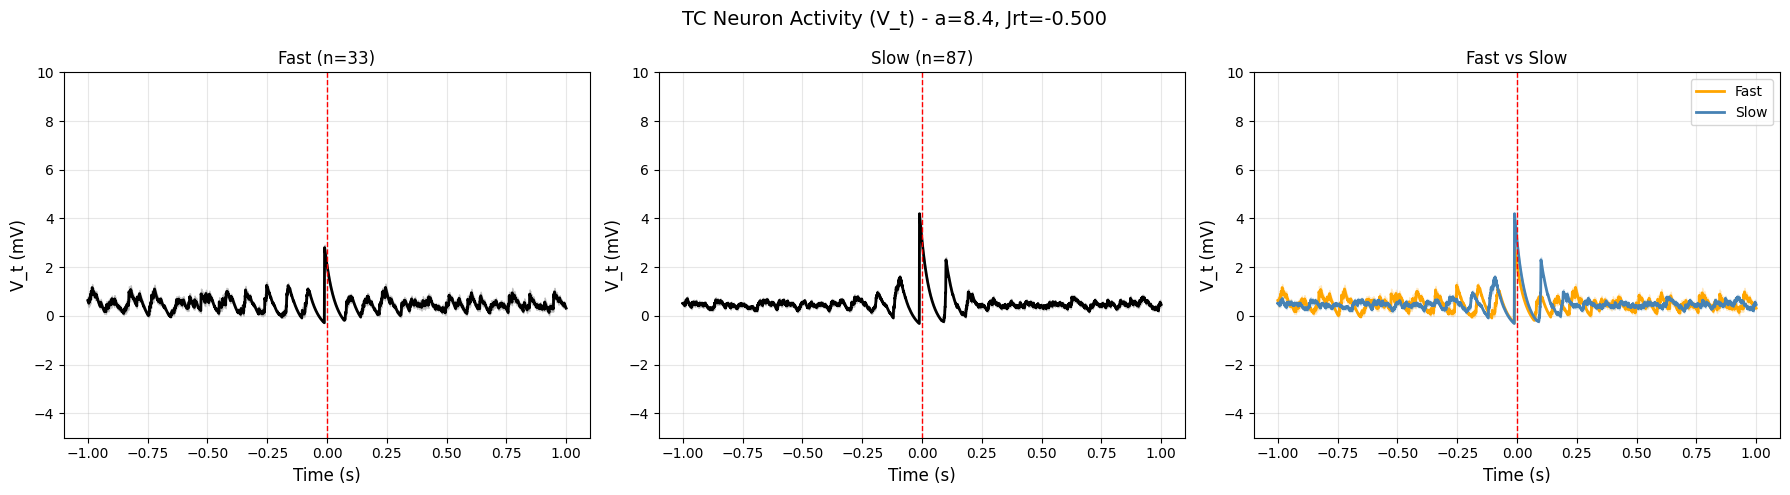

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# ========== 1. 参数设置 ==========
sf = 10000
window_before = 1.0
window_after = 1.0
window_samples = int((window_before + window_after) * sf)

CSV_PATH = "data/analysis_data/spindles_a8.4_Jrt_scan.csv"
DATA_DIR = "data/raw_data_a8.4_Jrt_scan"

# ========== 2. 读取 CSV ==========
df_spindles = pd.read_csv(CSV_PATH)
print(f"读取 {len(df_spindles)} 个纺锤波")

# ========== 3. 建立文件映射 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
file_map = {}
for file_path in file_list:
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    Jrt_val = float(parts[3])
    seed = int(parts[9])
    file_map[(Jrt_val, seed)] = file_path

# ========== 4. 提取信号片段 ==========
def extract_segment(file_path, peak_time, sf, window_samples):
    data = np.load(file_path, allow_pickle=True).item()
    V_t = data["V_t"]
    peak_idx = int(peak_time * sf)
    half_samples = window_samples // 2
    start_idx = peak_idx - half_samples
    end_idx = peak_idx + half_samples
    if start_idx < 0 or end_idx >= len(V_t):
        return None
    seg = V_t[start_idx:end_idx]
    if len(seg) != window_samples:
        return None
    return seg

Jrt_values = sorted(df_spindles['Jrt'].unique())
Jrt_groups = {}
for Jrt_val in Jrt_values:
    Jrt_groups[Jrt_val] = {"fast": [], "slow": []}

for _, row in df_spindles.iterrows():
    Jrt_val = row["Jrt"]
    seed = row["seed"]
    peak_time = row["peak"]
    spindle_type = row["type"]
    
    key = (Jrt_val, seed)
    if key not in file_map:
        continue
    
    seg = extract_segment(file_map[key], peak_time, sf, window_samples)
    if seg is not None:
        Jrt_groups[Jrt_val][spindle_type].append(seg)

# ========== 5. 计算均值和 SEM ==========
def compute_mean_sem(data_list):
    if len(data_list) == 0:
        return None, None
    data_array = np.array(data_list)
    mean = np.mean(data_array, axis=0)
    sem = np.std(data_array, axis=0) / np.sqrt(len(data_array))
    return mean, sem

time_axis = np.linspace(-window_before, window_after, window_samples)

print("\n各 Jrt 值纺锤波数量:")
for Jrt_val in Jrt_values:
    fast_count = len(Jrt_groups[Jrt_val]["fast"])
    slow_count = len(Jrt_groups[Jrt_val]["slow"])
    print(f"  Jrt={Jrt_val:.3f}: fast={fast_count}, slow={slow_count}")

# ========== 6. 每个 Jrt 值画三张图在一行 ==========
for Jrt_val in Jrt_values:
    fast_segs = Jrt_groups[Jrt_val]["fast"]
    slow_segs = Jrt_groups[Jrt_val]["slow"]
    
    fast_mean, fast_sem = compute_mean_sem(fast_segs)
    slow_mean, slow_sem = compute_mean_sem(slow_segs)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 子图1：快纺锤波
    ax = axes[0]
    if fast_mean is not None:
        ax.plot(time_axis, fast_mean, 'k-', linewidth=2)
        ax.fill_between(time_axis, fast_mean - fast_sem, fast_mean + fast_sem, 
                        color='black', alpha=0.2)
        ax.set_title(f'Fast (n={len(fast_segs)})', fontsize=12)
    else:
        ax.text(0, 0, 'No fast spindles', ha='center', va='center')
        ax.set_title('Fast (n=0)', fontsize=12)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('V_t (mV)', fontsize=12)
    ax.set_ylim(-5, 10)
    ax.grid(True, alpha=0.3)
    
    # 子图2：慢纺锤波
    ax = axes[1]
    if slow_mean is not None:
        ax.plot(time_axis, slow_mean, 'k-', linewidth=2)
        ax.fill_between(time_axis, slow_mean - slow_sem, slow_mean + slow_sem, 
                        color='black', alpha=0.2)
        ax.set_title(f'Slow (n={len(slow_segs)})', fontsize=12)
    else:
        ax.text(0, 0, 'No slow spindles', ha='center', va='center')
        ax.set_title('Slow (n=0)', fontsize=12)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('V_t (mV)', fontsize=12)
    ax.set_ylim(-5, 10)
    ax.grid(True, alpha=0.3)
    
    # 子图3：快慢叠加
    ax = axes[2]
    if fast_mean is not None:
        ax.plot(time_axis, fast_mean, 'orange', linewidth=2, label='Fast')
        ax.fill_between(time_axis, fast_mean - fast_sem, fast_mean + fast_sem, 
                        color='orange', alpha=0.2)
    if slow_mean is not None:
        ax.plot(time_axis, slow_mean, 'steelblue', linewidth=2, label='Slow')
        ax.fill_between(time_axis, slow_mean - slow_sem, slow_mean + slow_sem, 
                        color='steelblue', alpha=0.2)
    if fast_mean is None and slow_mean is None:
        ax.text(0, 0, 'No spindles', ha='center', va='center')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('V_t (mV)', fontsize=12)
    ax.set_title(f'Fast vs Slow', fontsize=12)
    ax.set_ylim(-5, 10)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'TC Neuron Activity (V_t) - a={8.4:.1f}, Jrt={Jrt_val:.3f}', fontsize=14)
    plt.tight_layout()
    plt.show()

读取 1929 个纺锤波

各 Jrt 值纺锤波数量:
  Jrt=-1.500: fast=7, slow=0
  Jrt=-1.400: fast=5, slow=0
  Jrt=-1.300: fast=55, slow=1
  Jrt=-1.200: fast=73, slow=1
  Jrt=-1.100: fast=90, slow=5
  Jrt=-1.000: fast=81, slow=8
  Jrt=-0.900: fast=80, slow=16
  Jrt=-0.800: fast=65, slow=59
  Jrt=-0.700: fast=76, slow=75
  Jrt=-0.675: fast=62, slow=92
  Jrt=-0.650: fast=50, slow=80
  Jrt=-0.625: fast=64, slow=84
  Jrt=-0.600: fast=61, slow=70
  Jrt=-0.575: fast=65, slow=80
  Jrt=-0.550: fast=54, slow=90
  Jrt=-0.525: fast=49, slow=92
  Jrt=-0.500: fast=33, slow=87


TypeError: 'NoneType' object is not iterable

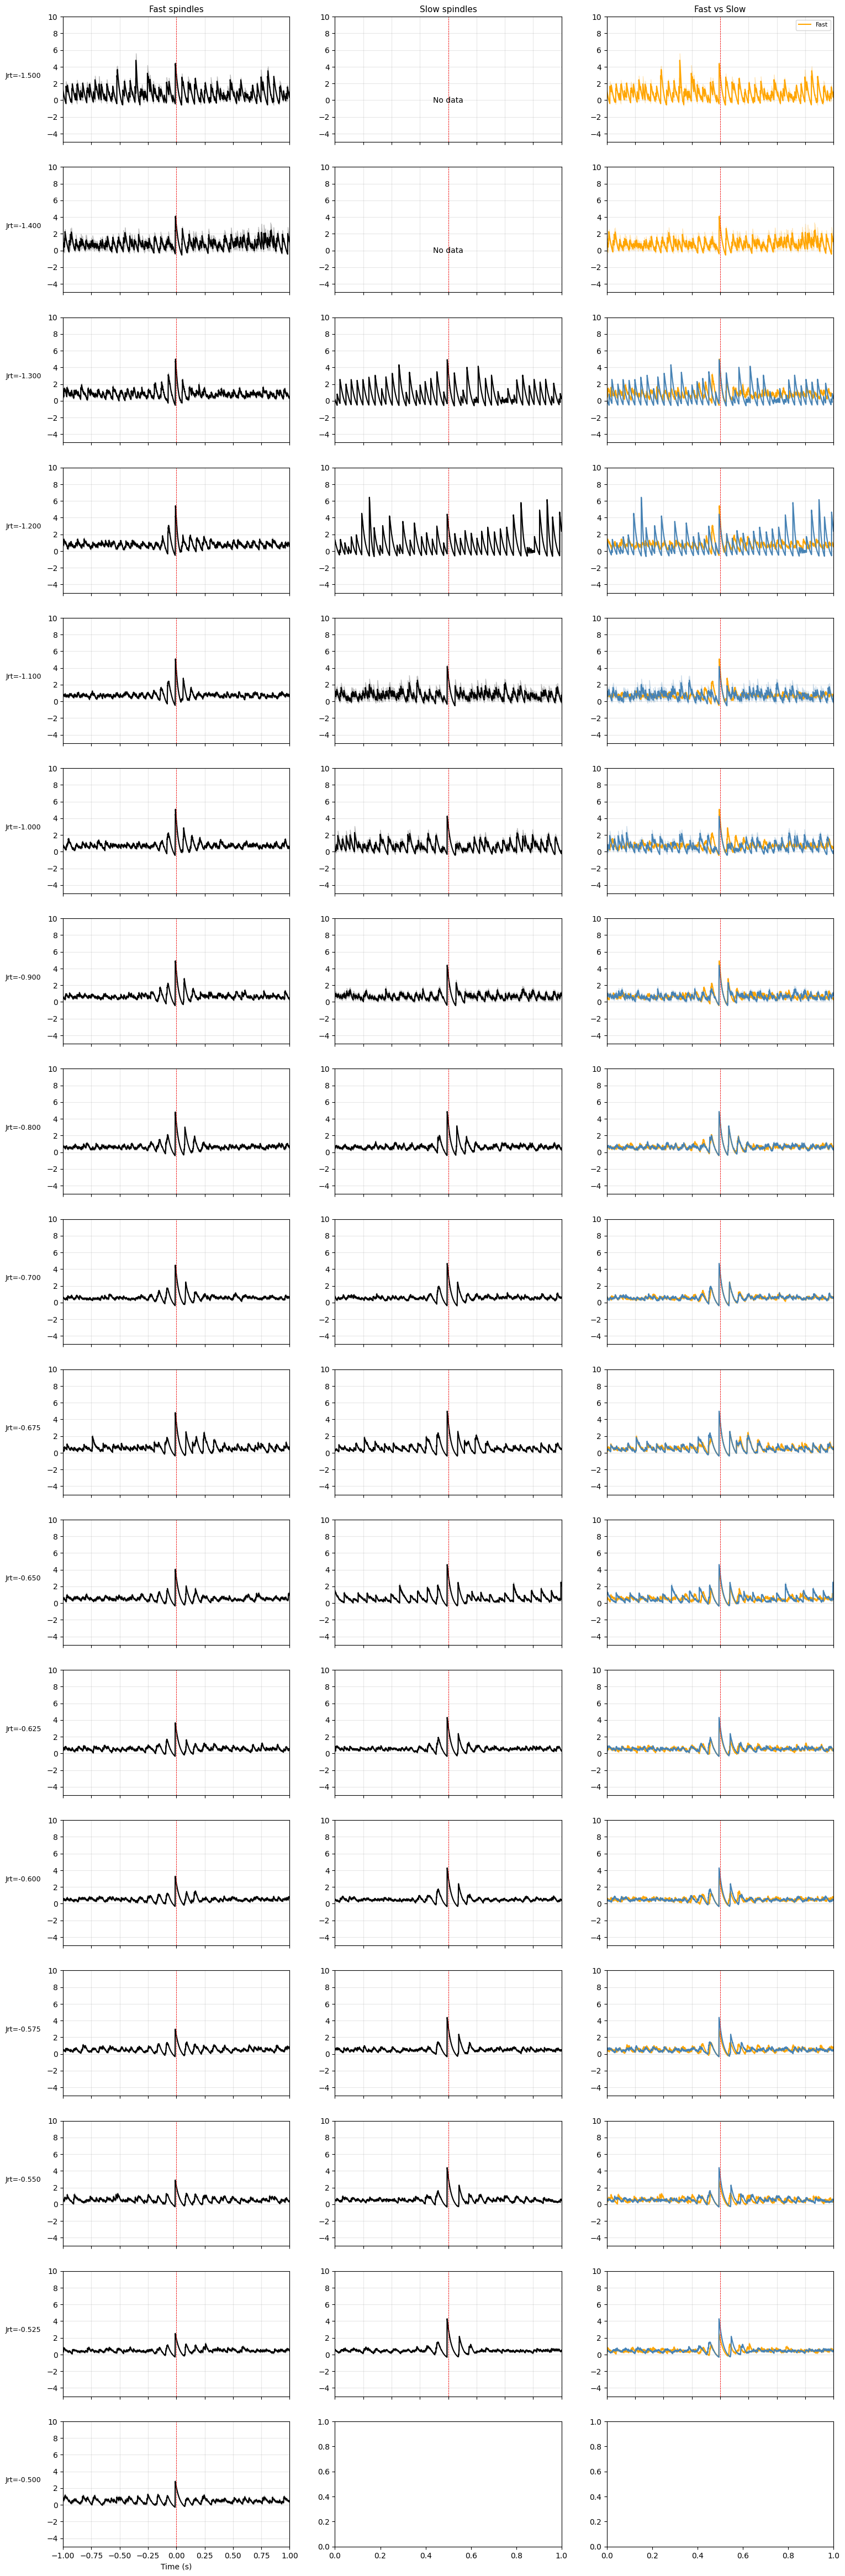

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# ========== 1. 参数设置 ==========
sf = 10000
window_before = 1.0
window_after = 1.0
window_samples = int((window_before + window_after) * sf)

CSV_PATH = "data/analysis_data/spindles_a8.4_Jrt_scan.csv"
DATA_DIR = "data/raw_data_a8.4_Jrt_scan"

# ========== 2. 读取 CSV ==========
df_spindles = pd.read_csv(CSV_PATH)
print(f"读取 {len(df_spindles)} 个纺锤波")

# ========== 3. 建立文件映射 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
file_map = {}
for file_path in file_list:
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    Jrt_val = float(parts[3])
    seed = int(parts[9])
    file_map[(Jrt_val, seed)] = file_path

# ========== 4. 提取信号片段 ==========
def extract_segment(file_path, peak_time, sf, window_samples):
    data = np.load(file_path, allow_pickle=True).item()
    V_t = data["V_t"]
    peak_idx = int(peak_time * sf)
    half_samples = window_samples // 2
    start_idx = peak_idx - half_samples
    end_idx = peak_idx + half_samples
    if start_idx < 0 or end_idx >= len(V_t):
        return None
    seg = V_t[start_idx:end_idx]
    if len(seg) != window_samples:
        return None
    return seg

Jrt_values = sorted(df_spindles['Jrt'].unique())
Jrt_groups = {}
for Jrt_val in Jrt_values:
    Jrt_groups[Jrt_val] = {"fast": [], "slow": []}

for _, row in df_spindles.iterrows():
    Jrt_val = row["Jrt"]
    seed = row["seed"]
    peak_time = row["peak"]
    spindle_type = row["type"]
    
    key = (Jrt_val, seed)
    if key not in file_map:
        continue
    
    seg = extract_segment(file_map[key], peak_time, sf, window_samples)
    if seg is not None:
        Jrt_groups[Jrt_val][spindle_type].append(seg)

# ========== 5. 计算均值和 SEM ==========
def compute_mean_sem(data_list):
    if len(data_list) == 0:
        return None, None
    data_array = np.array(data_list)
    mean = np.mean(data_array, axis=0)
    sem = np.std(data_array, axis=0) / np.sqrt(len(data_array))
    return mean, sem

time_axis = np.linspace(-window_before, window_after, window_samples)

print("\n各 Jrt 值纺锤波数量:")
for Jrt_val in Jrt_values:
    fast_count = len(Jrt_groups[Jrt_val]["fast"])
    slow_count = len(Jrt_groups[Jrt_val]["slow"])
    print(f"  Jrt={Jrt_val:.3f}: fast={fast_count}, slow={slow_count}")

# ========== 6. 所有 Jrt 值画在一张大图里 ==========
n_Jrt = len(Jrt_values)
fig, axes = plt.subplots(n_Jrt, 3, figsize=(18, 3.5 * n_Jrt))

if n_Jrt == 1:
    axes = axes.reshape(1, -1)

for row_idx, Jrt_val in enumerate(Jrt_values):
    fast_segs = Jrt_groups[Jrt_val]["fast"]
    slow_segs = Jrt_groups[Jrt_val]["slow"]
    
    fast_mean, fast_sem = compute_mean_sem(fast_segs)
    slow_mean, slow_sem = compute_mean_sem(slow_segs)
    
    # 列1：快纺锤波
    ax = axes[row_idx, 0]
    if fast_mean is not None:
        ax.plot(time_axis, fast_mean, 'k-', linewidth=1.5)
        ax.fill_between(time_axis, fast_mean - fast_sem, fast_mean + fast_sem, 
                        color='black', alpha=0.2)
        ax.set_ylabel(f'Jrt={Jrt_val:.3f}', fontsize=9, rotation=0, labelpad=30)
    else:
        ax.text(0, 0, 'No data', ha='center', va='center')
        ax.set_ylabel(f'Jrt={Jrt_val:.3f}', fontsize=9, rotation=0, labelpad=30)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=0.6)
    ax.set_xlim(-window_before, window_after)
    ax.set_ylim(-5, 10)
    ax.grid(True, alpha=0.3)
    if row_idx == 0:
        ax.set_title('Fast spindles', fontsize=11)
    if row_idx == n_Jrt - 1:
        ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_xticklabels([] if row_idx < n_Jrt - 1 else None)
    
    # 列2：慢纺锤波
    ax = axes[row_idx, 1]
    if slow_mean is not None:
        ax.plot(time_axis, slow_mean, 'k-', linewidth=1.5)
        ax.fill_between(time_axis, slow_mean - slow_sem, slow_mean + slow_sem, 
                        color='black', alpha=0.2)
    else:
        ax.text(0, 0, 'No data', ha='center', va='center')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=0.6)
    ax.set_xlim(-window_before, window_after)
    ax.set_ylim(-5, 10)
    ax.grid(True, alpha=0.3)
    if row_idx == 0:
        ax.set_title('Slow spindles', fontsize=11)
    if row_idx == n_Jrt - 1:
        ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_xticklabels([] if row_idx < n_Jrt - 1 else None)
    
    # 列3：快慢叠加
    ax = axes[row_idx, 2]
    if fast_mean is not None:
        ax.plot(time_axis, fast_mean, 'orange', linewidth=1.5, label='Fast')
        ax.fill_between(time_axis, fast_mean - fast_sem, fast_mean + fast_sem, 
                        color='orange', alpha=0.2)
    if slow_mean is not None:
        ax.plot(time_axis, slow_mean, 'steelblue', linewidth=1.5, label='Slow')
        ax.fill_between(time_axis, slow_mean - slow_sem, slow_mean + slow_sem, 
                        color='steelblue', alpha=0.2)
    if fast_mean is None and slow_mean is None:
        ax.text(0, 0, 'No data', ha='center', va='center')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=0.6)
    ax.set_xlim(-window_before, window_after)
    ax.set_ylim(-5, 10)
    ax.grid(True, alpha=0.3)
    if row_idx == 0:
        ax.set_title('Fast vs Slow', fontsize=11)
        ax.legend(fontsize=8, loc='upper right')
    if row_idx == n_Jrt - 1:
        ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_xticklabels([] if row_idx < n_Jrt - 1 else None)

plt.suptitle(f'TC Neuron Activity (V_t) - a=8.4, Jrt Scan', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

读取 1929 个纺锤波
Jrt 值: [-1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.675, -0.65, -0.625, -0.6, -0.575, -0.55, -0.525, -0.5]
找到 170 个匹配的文件

处理 Jrt=-1.5000
  纺锤波总数: 11
  快纺锤波: 11
  慢纺锤波: 0
  快片段: 7, 慢片段: 0

处理 Jrt=-1.4000
  纺锤波总数: 5
  快纺锤波: 5
  慢纺锤波: 0
  快片段: 5, 慢片段: 0

处理 Jrt=-1.3000
  纺锤波总数: 60
  快纺锤波: 59
  慢纺锤波: 1
  快片段: 53, 慢片段: 1

处理 Jrt=-1.2000
  纺锤波总数: 78
  快纺锤波: 77
  慢纺锤波: 1
  快片段: 70, 慢片段: 1

处理 Jrt=-1.1000
  纺锤波总数: 101
  快纺锤波: 96
  慢纺锤波: 5
  快片段: 89, 慢片段: 5

处理 Jrt=-1.0000
  纺锤波总数: 93
  快纺锤波: 85
  慢纺锤波: 8
  快片段: 78, 慢片段: 8

处理 Jrt=-0.9000
  纺锤波总数: 104
  快纺锤波: 86
  慢纺锤波: 18
  快片段: 75, 慢片段: 14

处理 Jrt=-0.8000
  纺锤波总数: 130
  快纺锤波: 67
  慢纺锤波: 63
  快片段: 61, 慢片段: 57

处理 Jrt=-0.7000
  纺锤波总数: 158
  快纺锤波: 78
  慢纺锤波: 80
  快片段: 73, 慢片段: 74

处理 Jrt=-0.6750
  纺锤波总数: 159
  快纺锤波: 66
  慢纺锤波: 93
  快片段: 61, 慢片段: 87

处理 Jrt=-0.6500
  纺锤波总数: 141
  快纺锤波: 55
  慢纺锤波: 86
  快片段: 48, 慢片段: 77

处理 Jrt=-0.6250
  纺锤波总数: 156
  快纺锤波: 67
  慢纺锤波: 89
  快片段: 61, 慢片段: 79

处理 Jrt=-0.6000
  纺锤波总数: 140
  快纺锤

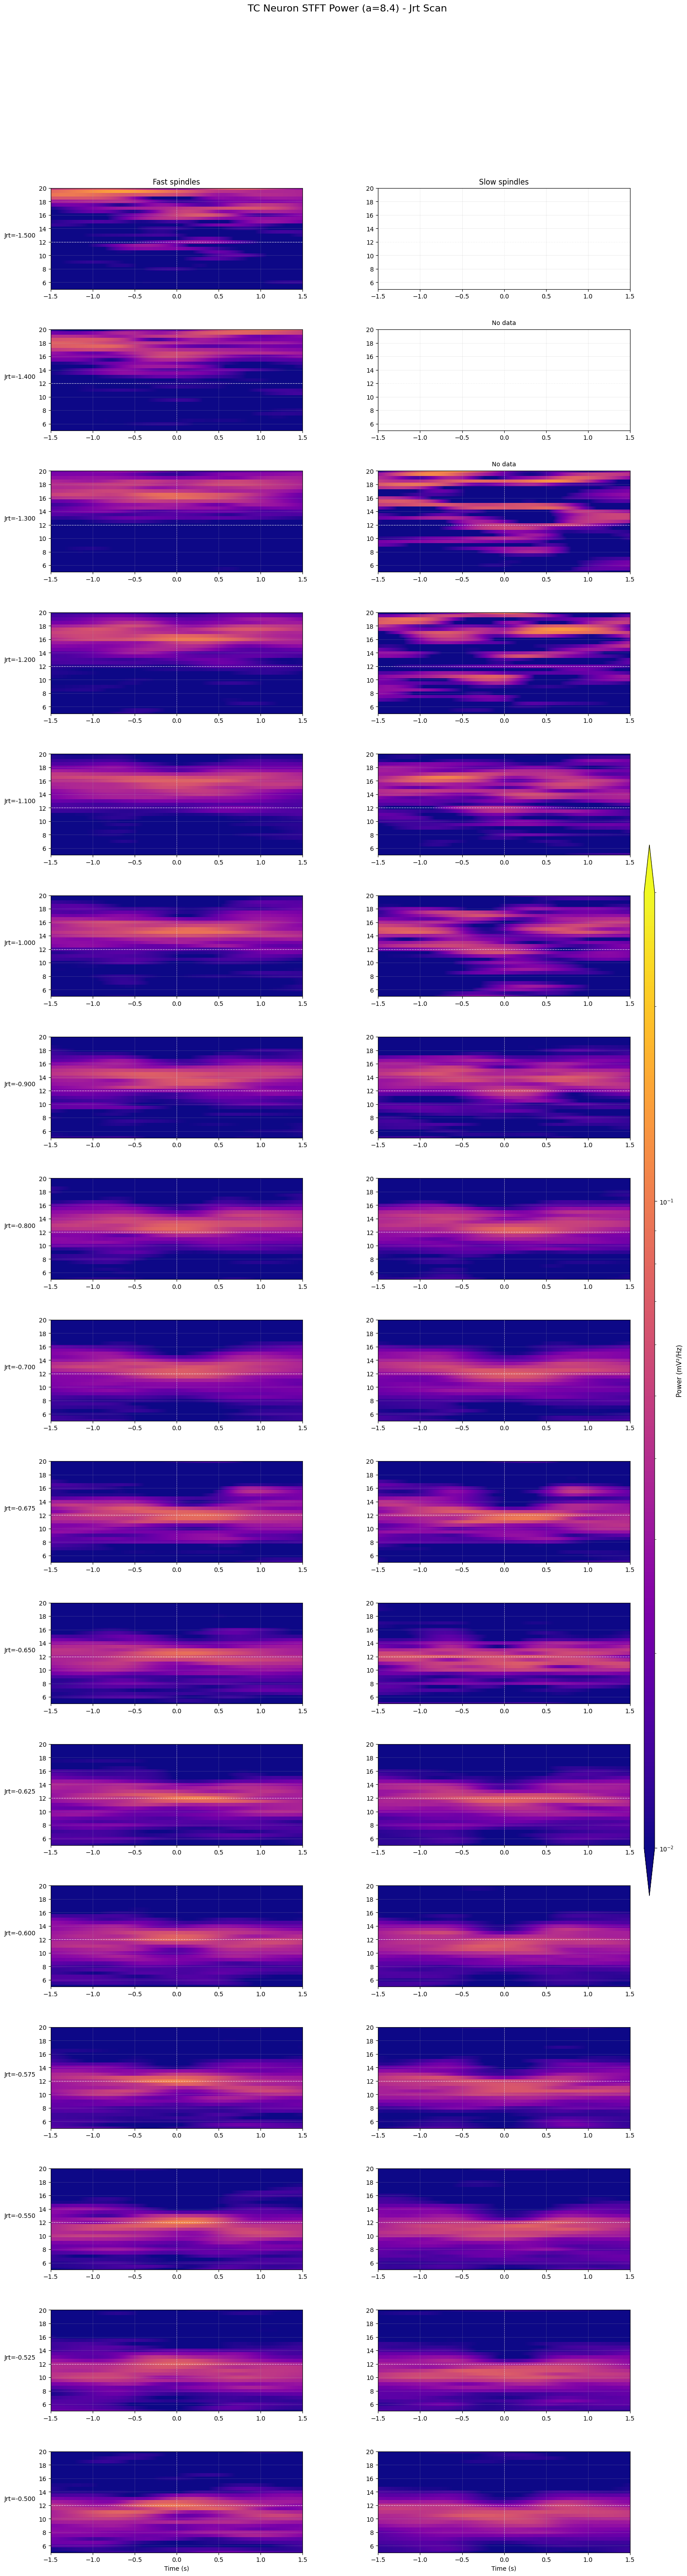

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import yasa
from yasa import stft_power
import matplotlib as mpl
import seaborn as sns

# ========== 1. 参数设置 ==========
sf = 10000  # 采样率
window_before = 1.5
window_after = 1.5
window_samples = int((window_before + window_after) * sf)

TARGET_A = 8.4
DATA_DIR = "data/raw_data_a8.4_Jrt_scan"
CSV_PATH = "data/analysis_data/spindles_a8.4_Jrt_scan.csv"

# STFT 参数
window = 2.0   # 秒
step = 0.2     # 秒
freqs_bounds = (0.5, 30.0)
vmin = 0.01
vmax = 0.3
CMAP = "plasma"
SXX_EPS = 1.1e-3

# ========== 2. 读取 CSV ==========
df = pd.read_csv(CSV_PATH)
print(f"读取 {len(df)} 个纺锤波")

Jrt_values = sorted(df['Jrt'].unique())
print(f"Jrt 值: {Jrt_values}")

# ========== 3. 建立文件映射 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
file_map = {}
for file_path in file_list:
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    Jrt_val = float(parts[3])
    seed = int(parts[9])
    file_map[(Jrt_val, seed)] = file_path
print(f"找到 {len(file_map)} 个匹配的文件")

# ========== 4. 提取信号片段 ==========
def extract_segment(file_path, peak_time, sf, window_samples):
    data = np.load(file_path, allow_pickle=True).item()
    V_t = data["V_t"]
    peak_idx = int(peak_time * sf)
    half_samples = window_samples // 2
    start_idx = peak_idx - half_samples
    end_idx = peak_idx + half_samples
    if start_idx < 0 or end_idx >= len(V_t):
        return None
    seg = V_t[start_idx:end_idx]
    if len(seg) != window_samples:
        return None
    return seg

# ========== 5. 计算平均 STFT 功率 ==========
def compute_average_stft(segments, sf, window, step, freqs_bounds):
    if len(segments) == 0:
        return None, None, None
    
    all_power = []
    common_f = None
    common_t = None
    
    for seg in segments:
        t_axis = np.linspace(-window_before, window_after, len(seg))
        seg_series = pd.Series(seg, index=t_axis)
        
        f, t, Sxx = stft_power(
            seg_series,
            sf,
            window=window,
            step=step,
            band=freqs_bounds,
            norm=True,
            interp=True,
        )
        
        t_aligned = t - window_before
        
        if common_f is None:
            common_f = f
            common_t = t_aligned
        
        all_power.append(Sxx)
    
    if len(all_power) == 0:
        return None, None, None
    
    min_t_len = min([p.shape[1] for p in all_power])
    all_power_cropped = [p[:, :min_t_len] for p in all_power]
    
    all_power_array = np.array(all_power_cropped)
    mean_power = np.mean(all_power_array, axis=0)
    
    t_axis = common_t[:min_t_len]
    
    return common_f, t_axis, mean_power

# ========== 6. 对每个 Jrt 值计算 STFT ==========
Jrt_data = {}

for Jrt_val in Jrt_values:
    print(f"\n处理 Jrt={Jrt_val:.4f}")
    
    df_filtered = df[df['Jrt'] == Jrt_val].copy()
    print(f"  纺锤波总数: {len(df_filtered)}")
    print(f"  快纺锤波: {len(df_filtered[df_filtered['type'] == 'fast'])}")
    print(f"  慢纺锤波: {len(df_filtered[df_filtered['type'] == 'slow'])}")
    
    if len(df_filtered) == 0:
        Jrt_data[Jrt_val] = {'fast': (None, None, None, 0), 'slow': (None, None, None, 0)}
        continue
    
    fast_segments = []
    slow_segments = []
    
    for _, row in df_filtered.iterrows():
        Jrt_val_row = row["Jrt"]
        seed = row["seed"]
        peak_time = row["peak"]
        spindle_type = row["type"]
        
        key = (Jrt_val_row, seed)
        if key not in file_map:
            continue
        
        seg = extract_segment(file_map[key], peak_time, sf, window_samples)
        if seg is not None:
            if spindle_type == 'fast':
                fast_segments.append(seg)
            else:
                slow_segments.append(seg)
    
    print(f"  快片段: {len(fast_segments)}, 慢片段: {len(slow_segments)}")
    
    fast_f, fast_t, fast_power = compute_average_stft(fast_segments, sf, window, step, freqs_bounds)
    slow_f, slow_t, slow_power = compute_average_stft(slow_segments, sf, window, step, freqs_bounds)
    
    Jrt_data[Jrt_val] = {
        'fast': (fast_f, fast_t, fast_power, len(fast_segments)),
        'slow': (slow_f, slow_t, slow_power, len(slow_segments))
    }

# ========== 7. 所有 Jrt 值画在一张大图里 ==========
n_Jrt = len(Jrt_values)
fig = plt.figure(figsize=(16, 3.5 * n_Jrt))
gs = fig.add_gridspec(nrows=n_Jrt, ncols=2)
gs.update(wspace=0.3, hspace=0.4)

# 记录第一个有效的 im 用于颜色条
first_im = None

for row_idx, Jrt_val in enumerate(Jrt_values):
    fast_f, fast_t, fast_power, fast_n = Jrt_data[Jrt_val]['fast']
    slow_f, slow_t, slow_power, slow_n = Jrt_data[Jrt_val]['slow']
    
    # 左图：快纺锤波
    ax = fig.add_subplot(gs[row_idx, 0])
    if fast_power is not None and fast_power.size > 0:
        im = ax.pcolormesh(
            fast_t,
            fast_f,
            fast_power + SXX_EPS,
            cmap=CMAP,
            rasterized=True,
            norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax),
        )
        if first_im is None:
            first_im = im
        ax.set_ylabel(f'Jrt={Jrt_val:.3f}', fontsize=10, rotation=0, labelpad=30)
    else:
        ax.text(0, 0, 'No data', ha='center', va='center')
        ax.set_ylabel(f'Jrt={Jrt_val:.3f}', fontsize=10, rotation=0, labelpad=30)
    
    # 添加 12 Hz 分界线（白色虚线）
    ax.axhline(y=12, color='white', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.axvline(x=0, color='white', linestyle='--', linewidth=0.6, alpha=0.6)
    ax.set_xlim(-window_before, window_after)
    ax.set_ylim(5, 20)
    ax.grid(True, alpha=0.2)
    if row_idx == 0:
        ax.set_title('Fast spindles', fontsize=12)
    if row_idx == n_Jrt - 1:
        ax.set_xlabel('Time (s)', fontsize=10)
    
    # 右图：慢纺锤波
    ax = fig.add_subplot(gs[row_idx, 1])
    if slow_power is not None and slow_power.size > 0:
        im = ax.pcolormesh(
            slow_t,
            slow_f,
            slow_power + SXX_EPS,
            cmap=CMAP,
            rasterized=True,
            norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax),
        )
        if first_im is None:
            first_im = im
    else:
        ax.text(0, 0, 'No data', ha='center', va='center')
    
    # 添加 12 Hz 分界线（白色虚线）
    ax.axhline(y=12, color='white', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.axvline(x=0, color='white', linestyle='--', linewidth=0.6, alpha=0.6)
    ax.set_xlim(-window_before, window_after)
    ax.set_ylim(5, 20)
    ax.grid(True, alpha=0.2)
    if row_idx == 0:
        ax.set_title('Slow spindles', fontsize=12)
    if row_idx == n_Jrt - 1:
        ax.set_xlabel('Time (s)', fontsize=10)

# 添加颜色条
cbar_ax = fig.add_axes([0.92, 0.3, 0.015, 0.4])
cbar = mpl.colorbar.ColorbarBase(
    cbar_ax,
    cmap=plt.get_cmap(CMAP),
    norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax),
    orientation="vertical",
    extend="both",
)
cbar.set_label("Power (mV²/Hz)", fontsize=11)

plt.suptitle(f'TC Neuron STFT Power (a={TARGET_A}) - Jrt Scan', fontsize=16, y=1.02)

# 不使用 tight_layout，改用 subplots_adjust
plt.subplots_adjust(top=0.95, bottom=0.05, left=0.08, right=0.90)
plt.show()